# Begin

In [44]:
import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle

from datetime import datetime
from joblib import Parallel, delayed
from scipy.stats import _continuous_distns, genpareto, norm, t, norminvgauss
from statsmodels.stats.diagnostic import acorr_ljungbox
from typing import Iterable

from funvol.detrended_price.detrended_price import load_underlying
from utils import get_file_list, load_processed_bhav
from plots import *

logging.basicConfig()
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

rng = np.random.default_rng(seed=42)

# Inverted IV

In [2]:
data_reserve = "./inverting_iv/artefacts/"
files = get_file_list(data_reserve, glob="*-allbhav-iv.csv")
df = pd.concat([load_processed_bhav(f) for f in files])

df = (
    df
    .reset_index()
    .sort_values(["date", "expiry_date", "strike"])
    .set_index("date")
)

logger.info(f"{datetime.now()}: Loaded processed Bhavcopies: {df.shape}.")

INFO:utils:2026-10-01 04:57:13.951705: Found 2 files.
INFO:__main__:2026-10-01 04:57:14.033475: Loaded processed Bhavcopies: (10076, 11).


## Implied Volatility smiles per day
For specifically the October 2019 expiries.

INFO:plots:2026-10-01 04:57:15.039294: Filtering expiries to lie within 2019-10-03 and 2019-10-31.
INFO:plots:2026-10-01 04:57:15.042246: Plotting daily implied volatility curves for 5 expiries...
INFO:plots:2026-10-01 04:57:15.142890: Expiry date 2019-10-24 00:00:00 has no data.
INFO:plots:2026-10-01 04:57:15.165891: Expiry date 2019-10-24 00:00:00 has no data.
INFO:plots:2026-10-01 04:57:15.180964: Expiry date 2019-10-24 00:00:00 has no data.
INFO:plots:2026-10-01 04:57:15.676771: Plot generated.


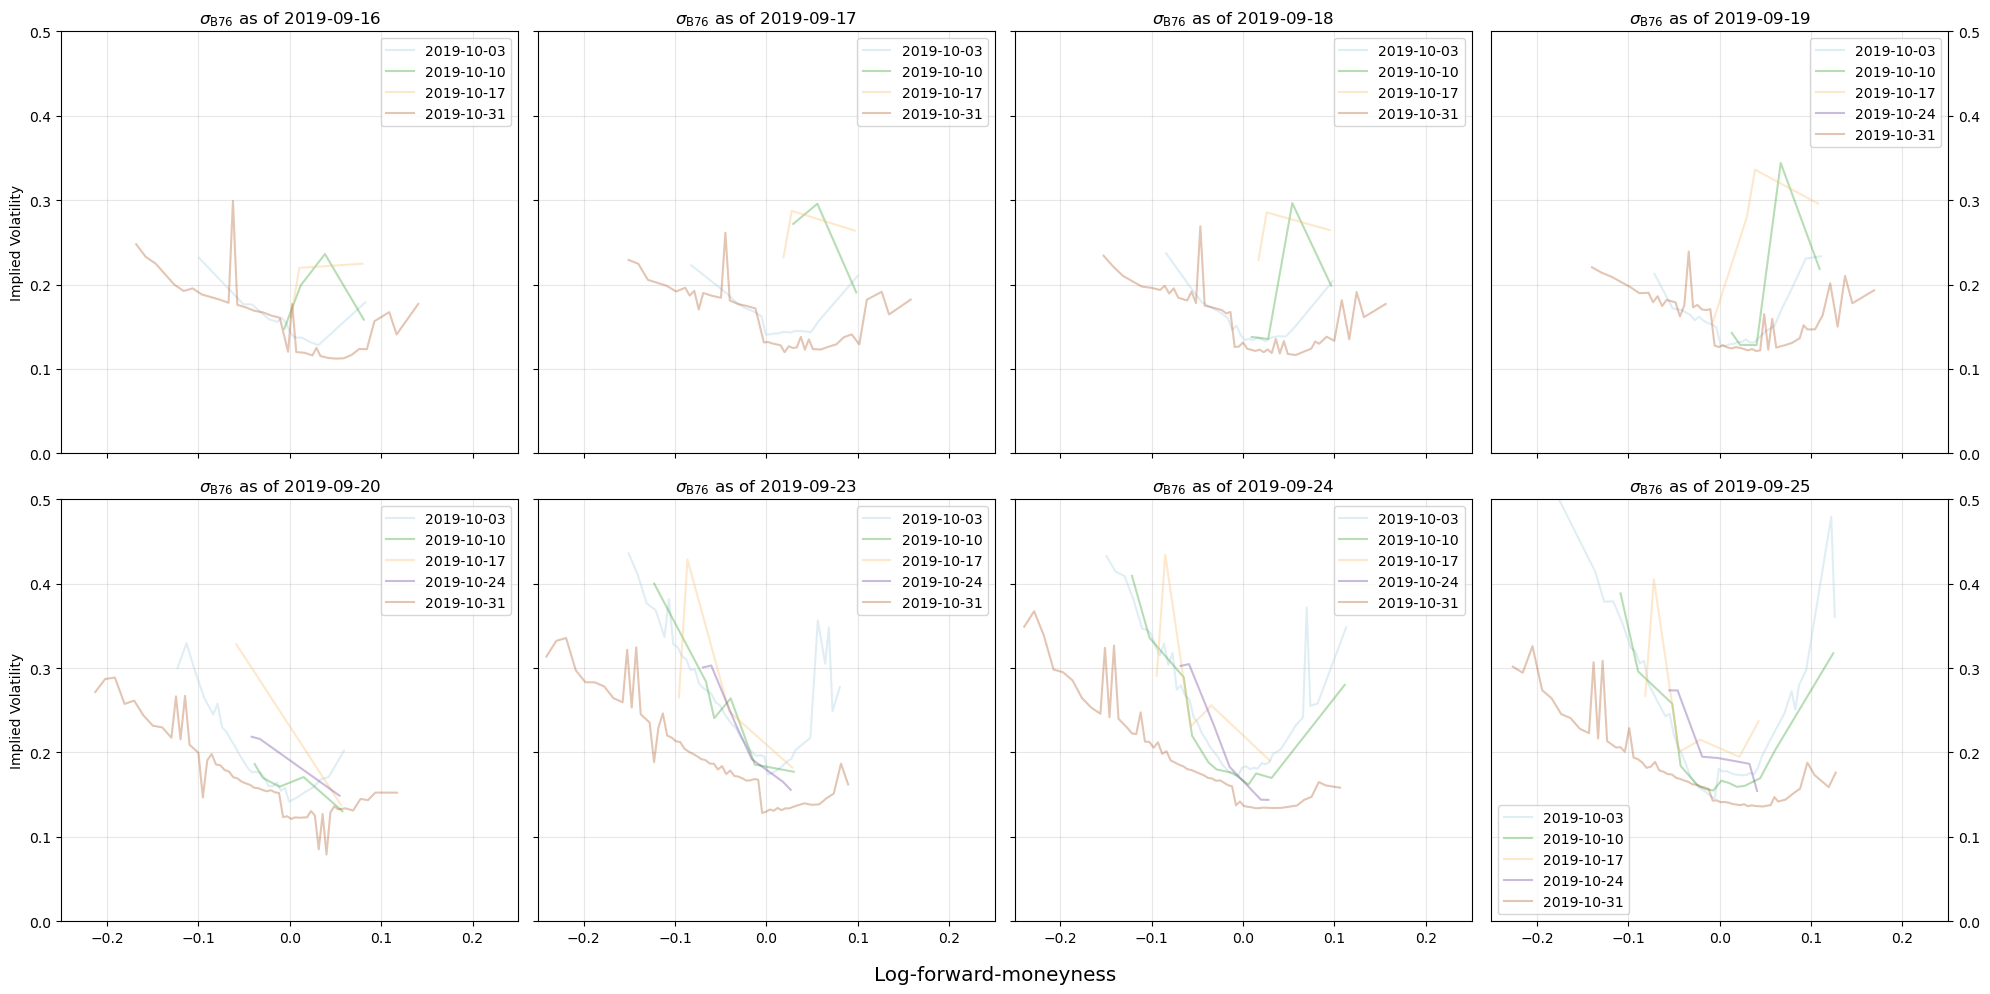

In [3]:
plot_daily_smiles(
    df,
    if_var       = False,
    start        = "2019-09-16",
    end          = "2019-09-25",
    expiry_start = "2019-10-03",
    expiry_end   = "2019-10-31",
)

plt.show()

## Total Implied Variance smiles per day
For specifically the October 2019 expiries.

INFO:plots:2026-10-01 04:57:17.338230: Filtering expiries to lie within 2019-10-03 and 2019-10-31.
INFO:plots:2026-10-01 04:57:17.343585: Plotting daily total implied variance curves for 5 expiries...
INFO:plots:2026-10-01 04:57:17.427101: Expiry date 2019-10-24 00:00:00 has no data.
INFO:plots:2026-10-01 04:57:17.445099: Expiry date 2019-10-24 00:00:00 has no data.
INFO:plots:2026-10-01 04:57:17.464382: Expiry date 2019-10-24 00:00:00 has no data.
INFO:plots:2026-10-01 04:57:17.907081: Plot generated.


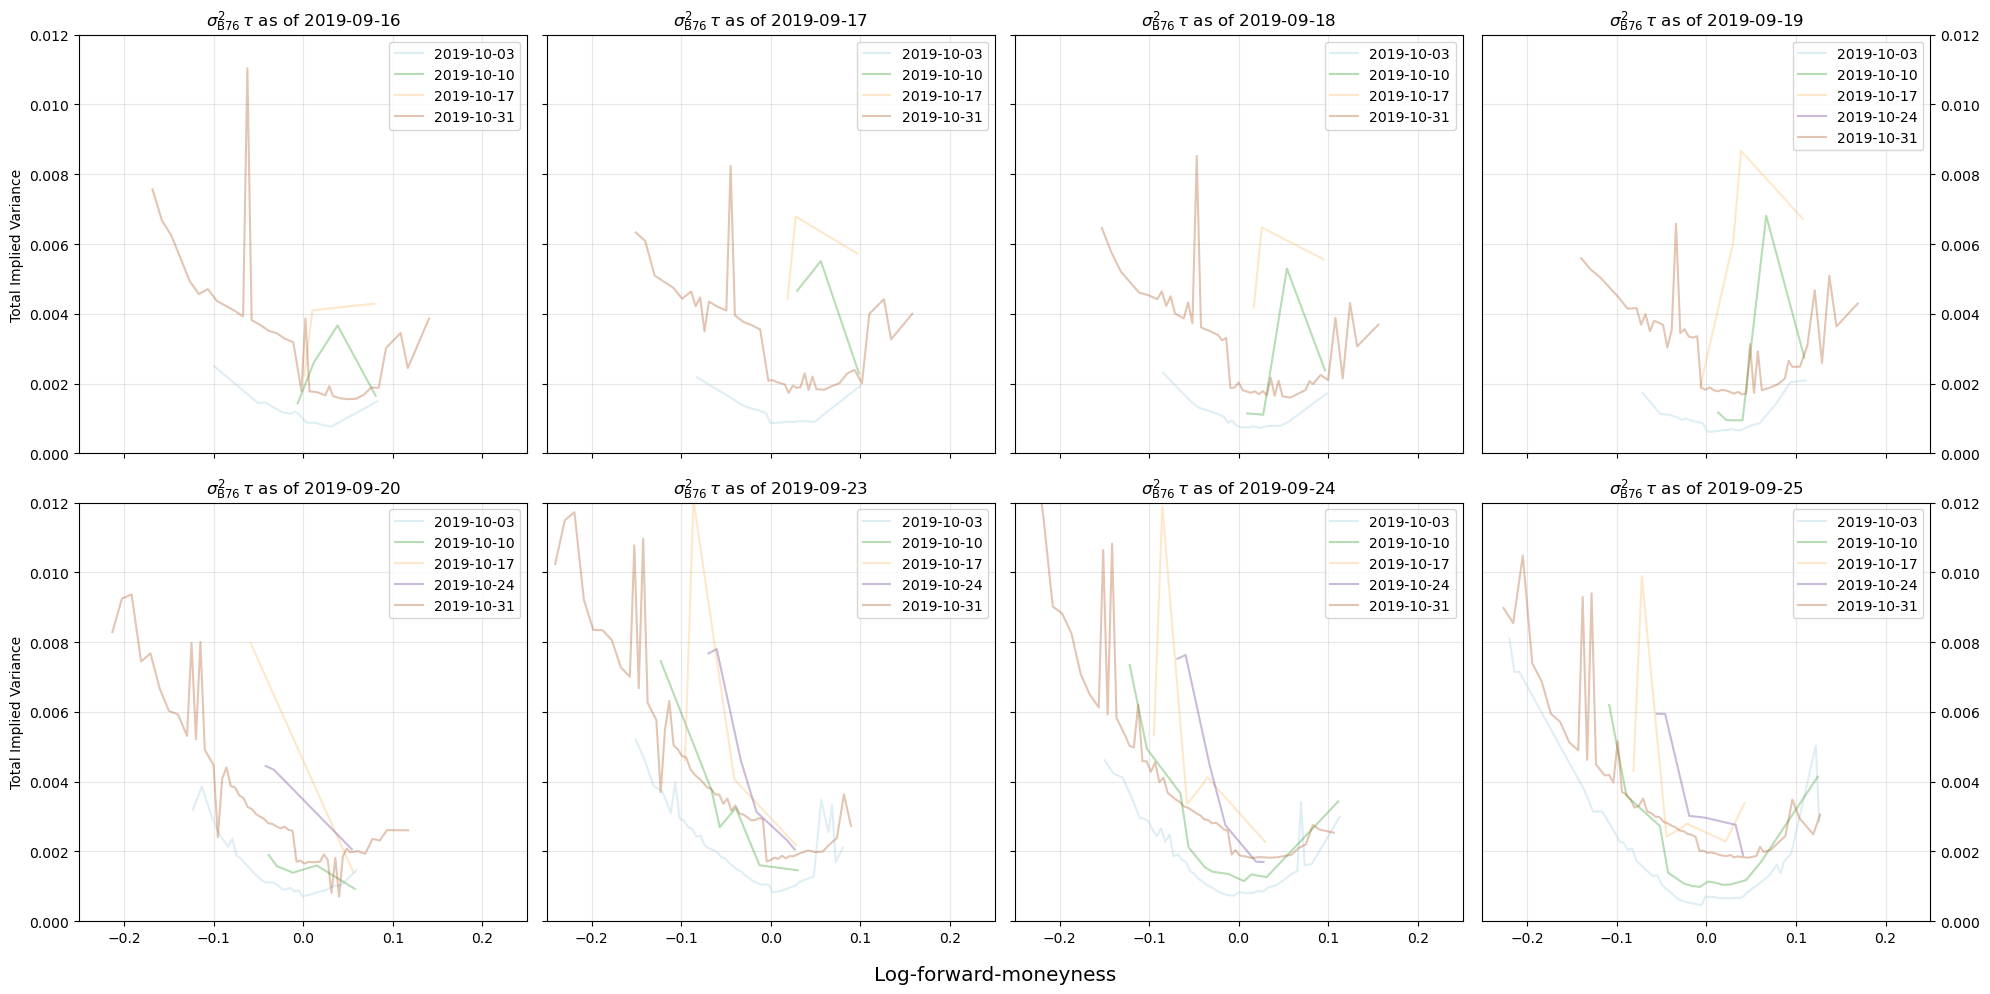

In [4]:
plot_daily_smiles(
    df,
    if_var       = True,
    start        = "2019-09-16",
    end          = "2019-09-25",
    expiry_start = "2019-10-03",
    expiry_end   = "2019-10-31",
)

plt.show()

# SSVI

In [5]:
# apparently, using `np.save()` and `np.load()` for dictionaries loads the dict
# as a 1D array. In what world is this appropriate? Jeez.
ssvi_artefact = "./ssvi/artefacts/2026-09-16_20-09-45_ssvi_fitted_params.pkl"

with open(ssvi_artefact, "rb") as f:
    ssvi_params = pickle.load(f)

## SSVI fits

INFO:plots:2026-10-01 04:57:48.412272: Filtering expiries to lie within 2019-10-03 and 2019-10-31.
INFO:plots:2026-10-01 04:57:48.416005: Plotting for 6 days and 5 expiries.
INFO:plots:2026-10-01 04:57:50.304060: Plot generated.


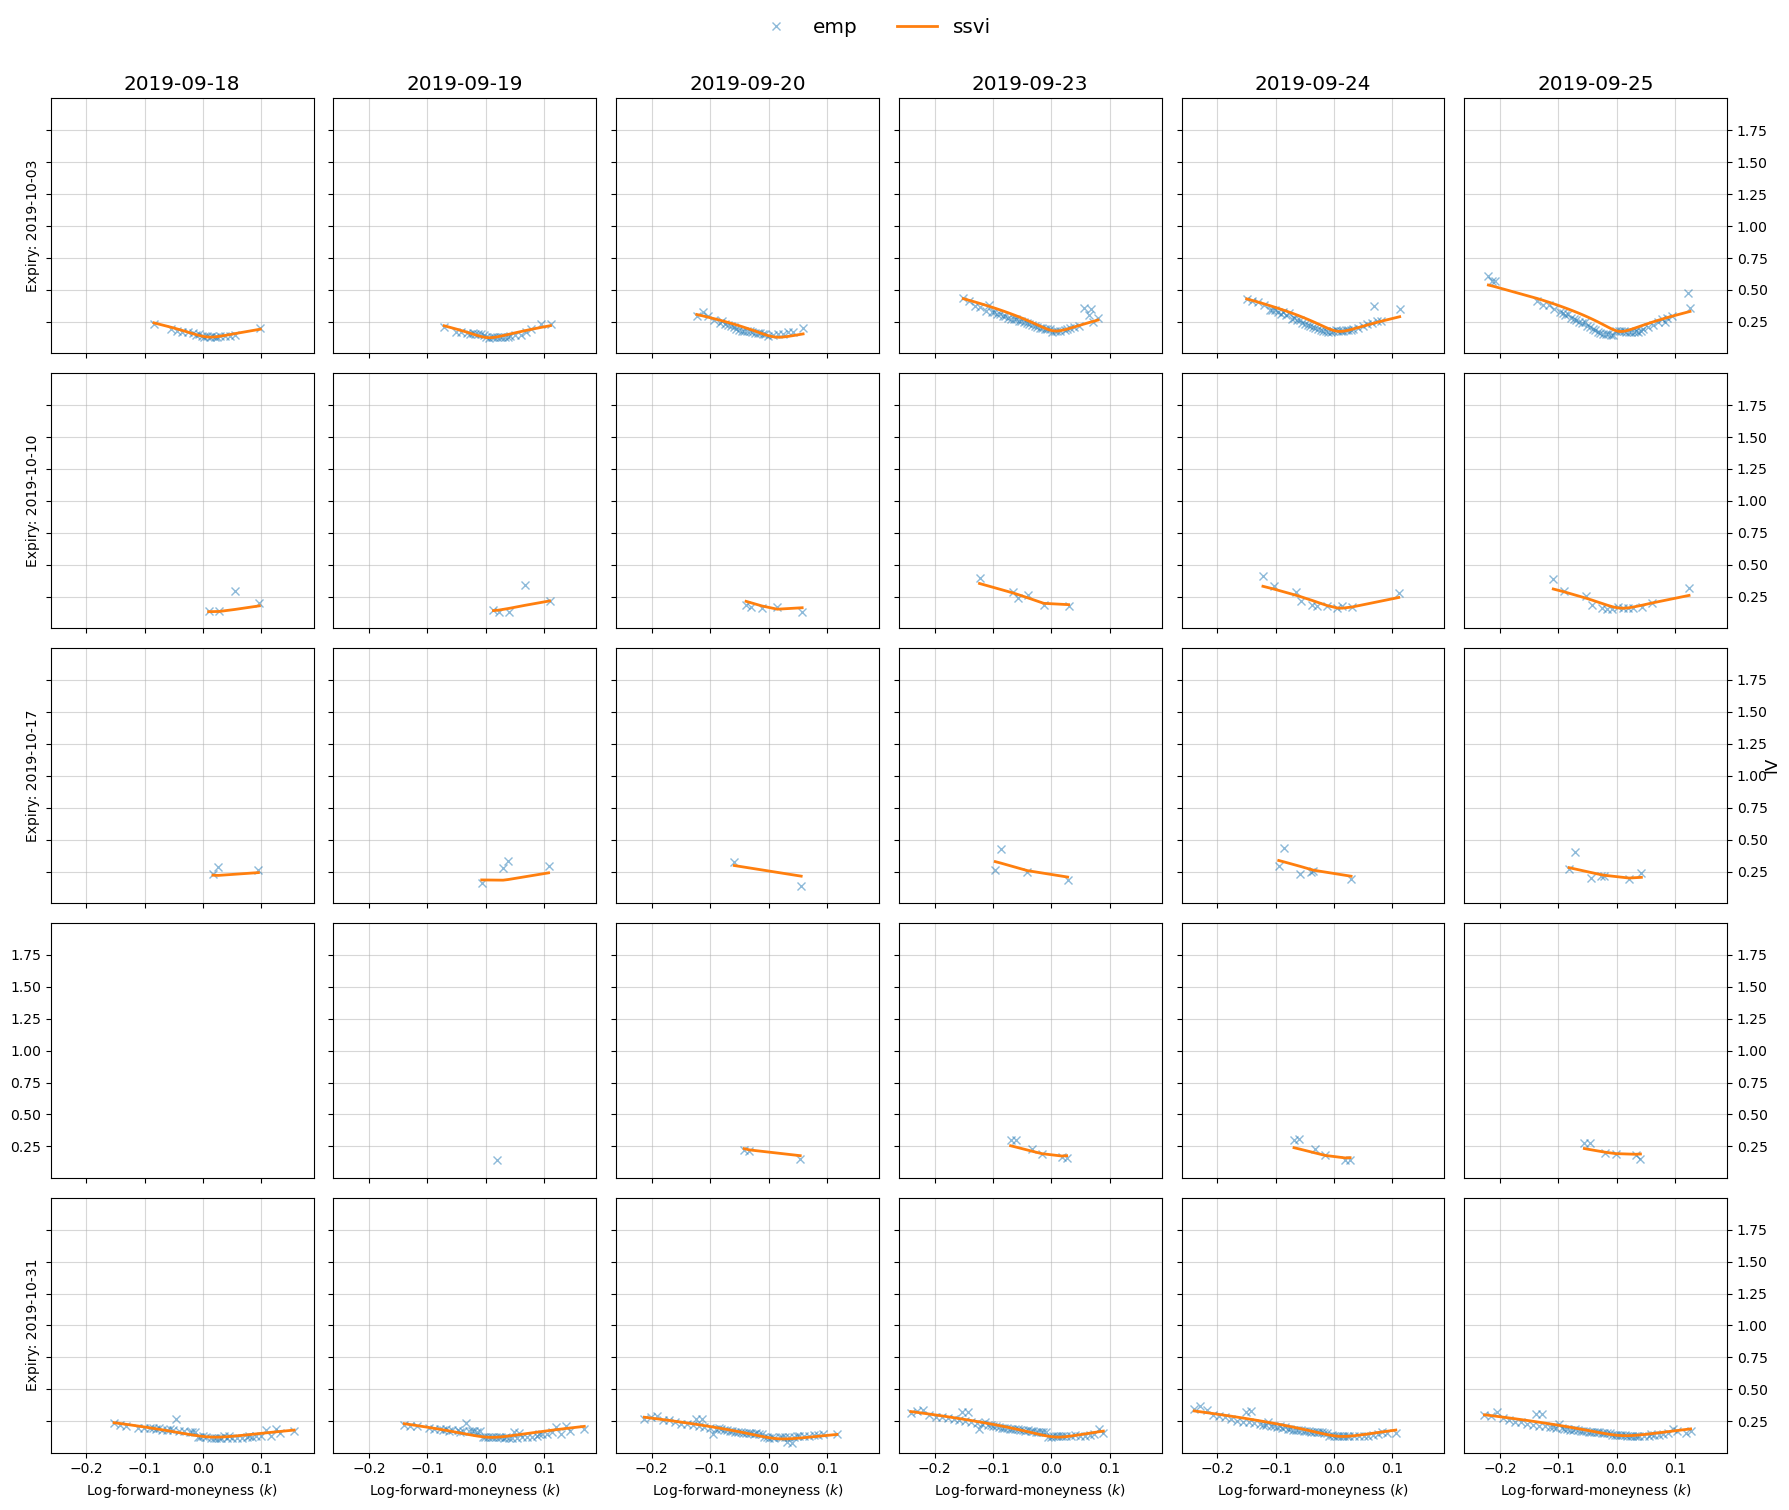

In [6]:
plot_ssvi_curves(
    ssvi_params  = ssvi_params,
    df_otm       = df,
    start        = "2019-09-18",
    end          = "2019-09-25",
    expiry_start = "2019-10-03",
    expiry_end   = "2019-10-31",
)

plt.show()

## SSVI fitted parameters

INFO:plots:2026-10-01 04:57:53.933539: Computing 25-Delta Risk Reversals...
INFO:ssvi.metrics:2026-10-01 04:57:53.936120: Computed option Delta(s).
INFO:ssvi.metrics:2026-10-01 04:57:53.937329: Computed option Delta(s).
INFO:ssvi.metrics:2026-10-01 04:57:53.938623: Computed option Delta(s).
INFO:ssvi.metrics:2026-10-01 04:57:53.939921: Computed option Delta(s).
INFO:ssvi.metrics:2026-10-01 04:57:53.940986: Computed option Delta(s).
INFO:ssvi.metrics:2026-10-01 04:57:53.942155: Computed option Delta(s).
INFO:ssvi.metrics:2026-10-01 04:57:53.943365: Computed option Delta(s).
INFO:ssvi.metrics:2026-10-01 04:57:53.944691: Computed option Delta(s).
INFO:ssvi.metrics:2026-10-01 04:57:53.945829: Computed option Delta(s).
INFO:ssvi.metrics:2026-10-01 04:57:53.946914: Computed option Delta(s).
INFO:ssvi.metrics:2026-10-01 04:57:53.948157: Computed option Delta(s).
INFO:ssvi.metrics:2026-10-01 04:57:53.949356: Computed option Delta(s).
INFO:ssvi.metrics:2026-10-01 04:57:53.950446: Computed optio

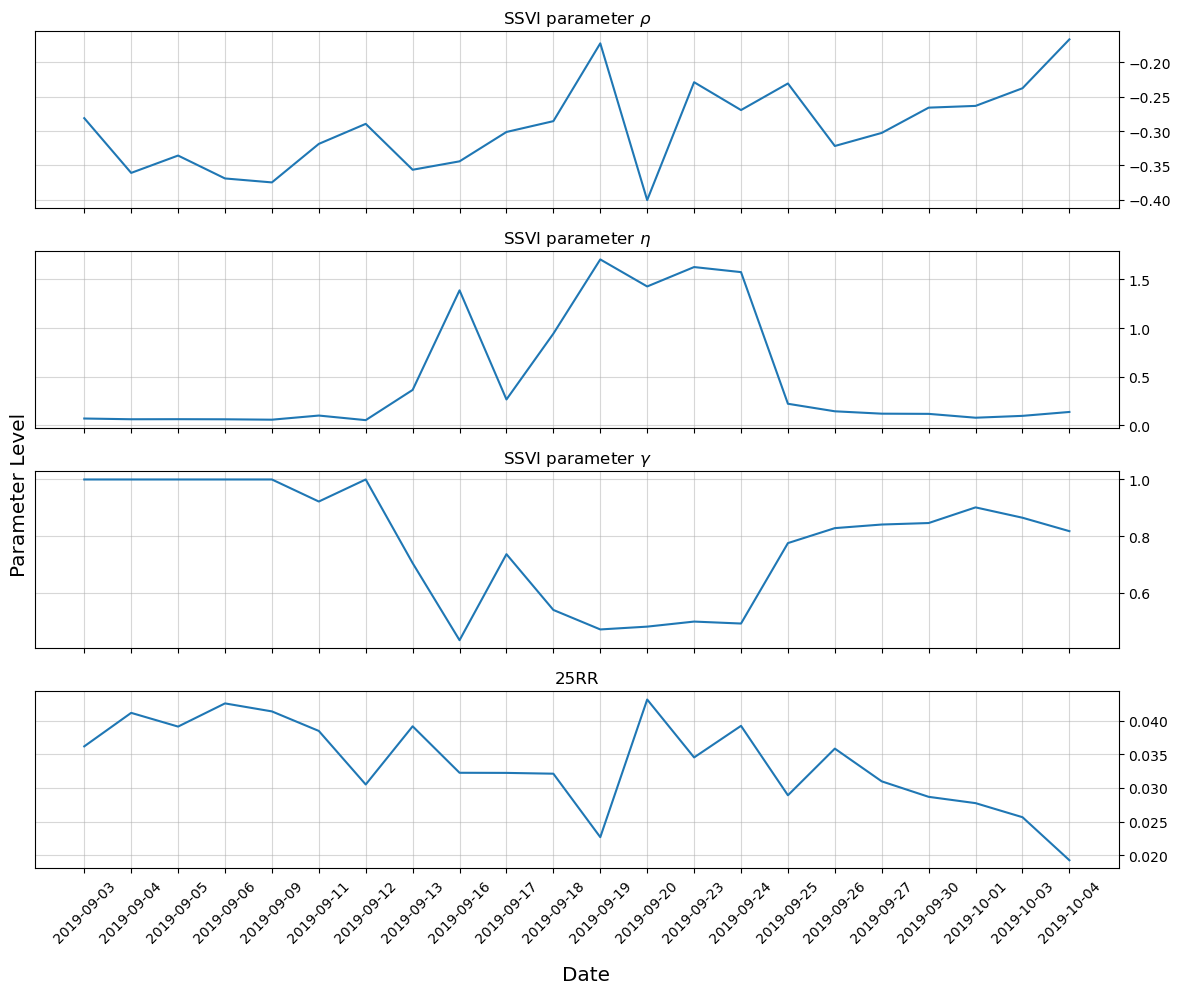

In [7]:
plot_ssvi_parameters(ssvi_params, rr_Delta=0.25)
plt.show()

## SSVI surfaces

INFO:plots:2026-10-01 04:58:02.170094: Plotting SSVI surfaces...
INFO:plots:2026-10-01 04:58:02.296575: Beginning interpolation...
INFO:plots:2026-10-01 04:58:02.659227: Plot generated.


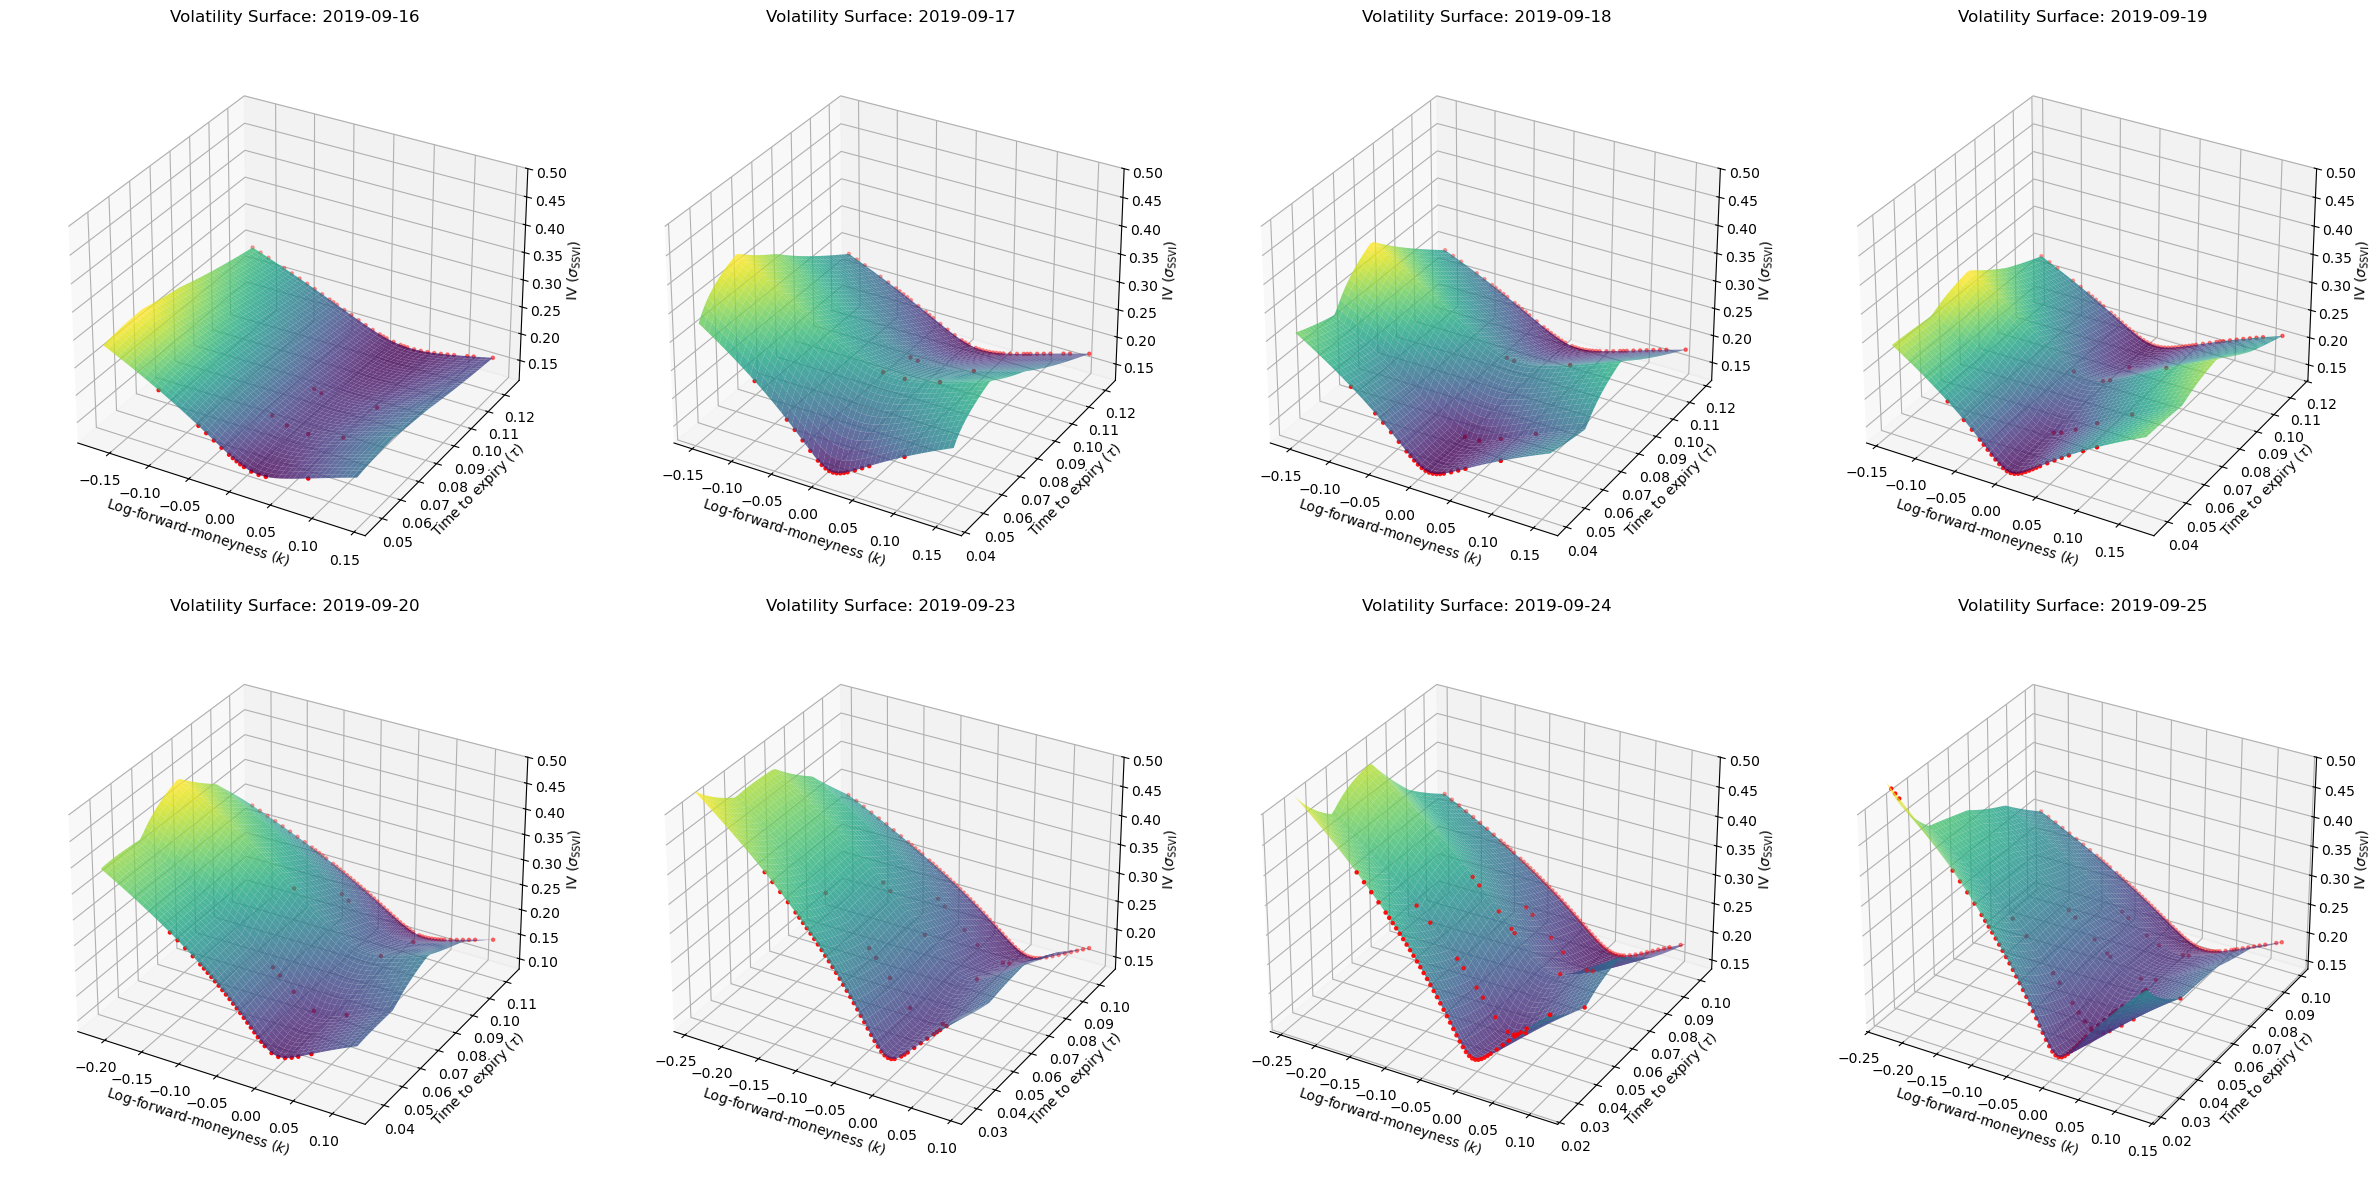

In [8]:
plot_ssvi_interp_surfaces(
    ssvi_params,
    start = "2019-09-16",
    end   = "2019-09-25"
)

plt.show()

# FuNVol

## OptionMetrics surfaces

In [9]:
ometrics_artefact = "./funvol/option_metrics/artefacts/2026-09-16_22-00-35_om-surfaces.csv"
om_surface = pd.read_csv(ometrics_artefact, parse_dates=[0])

INFO:plots:2026-10-01 04:58:08.753642: Plotting OM surfaces...
INFO:plots:2026-10-01 04:58:09.363172: Plot generated.


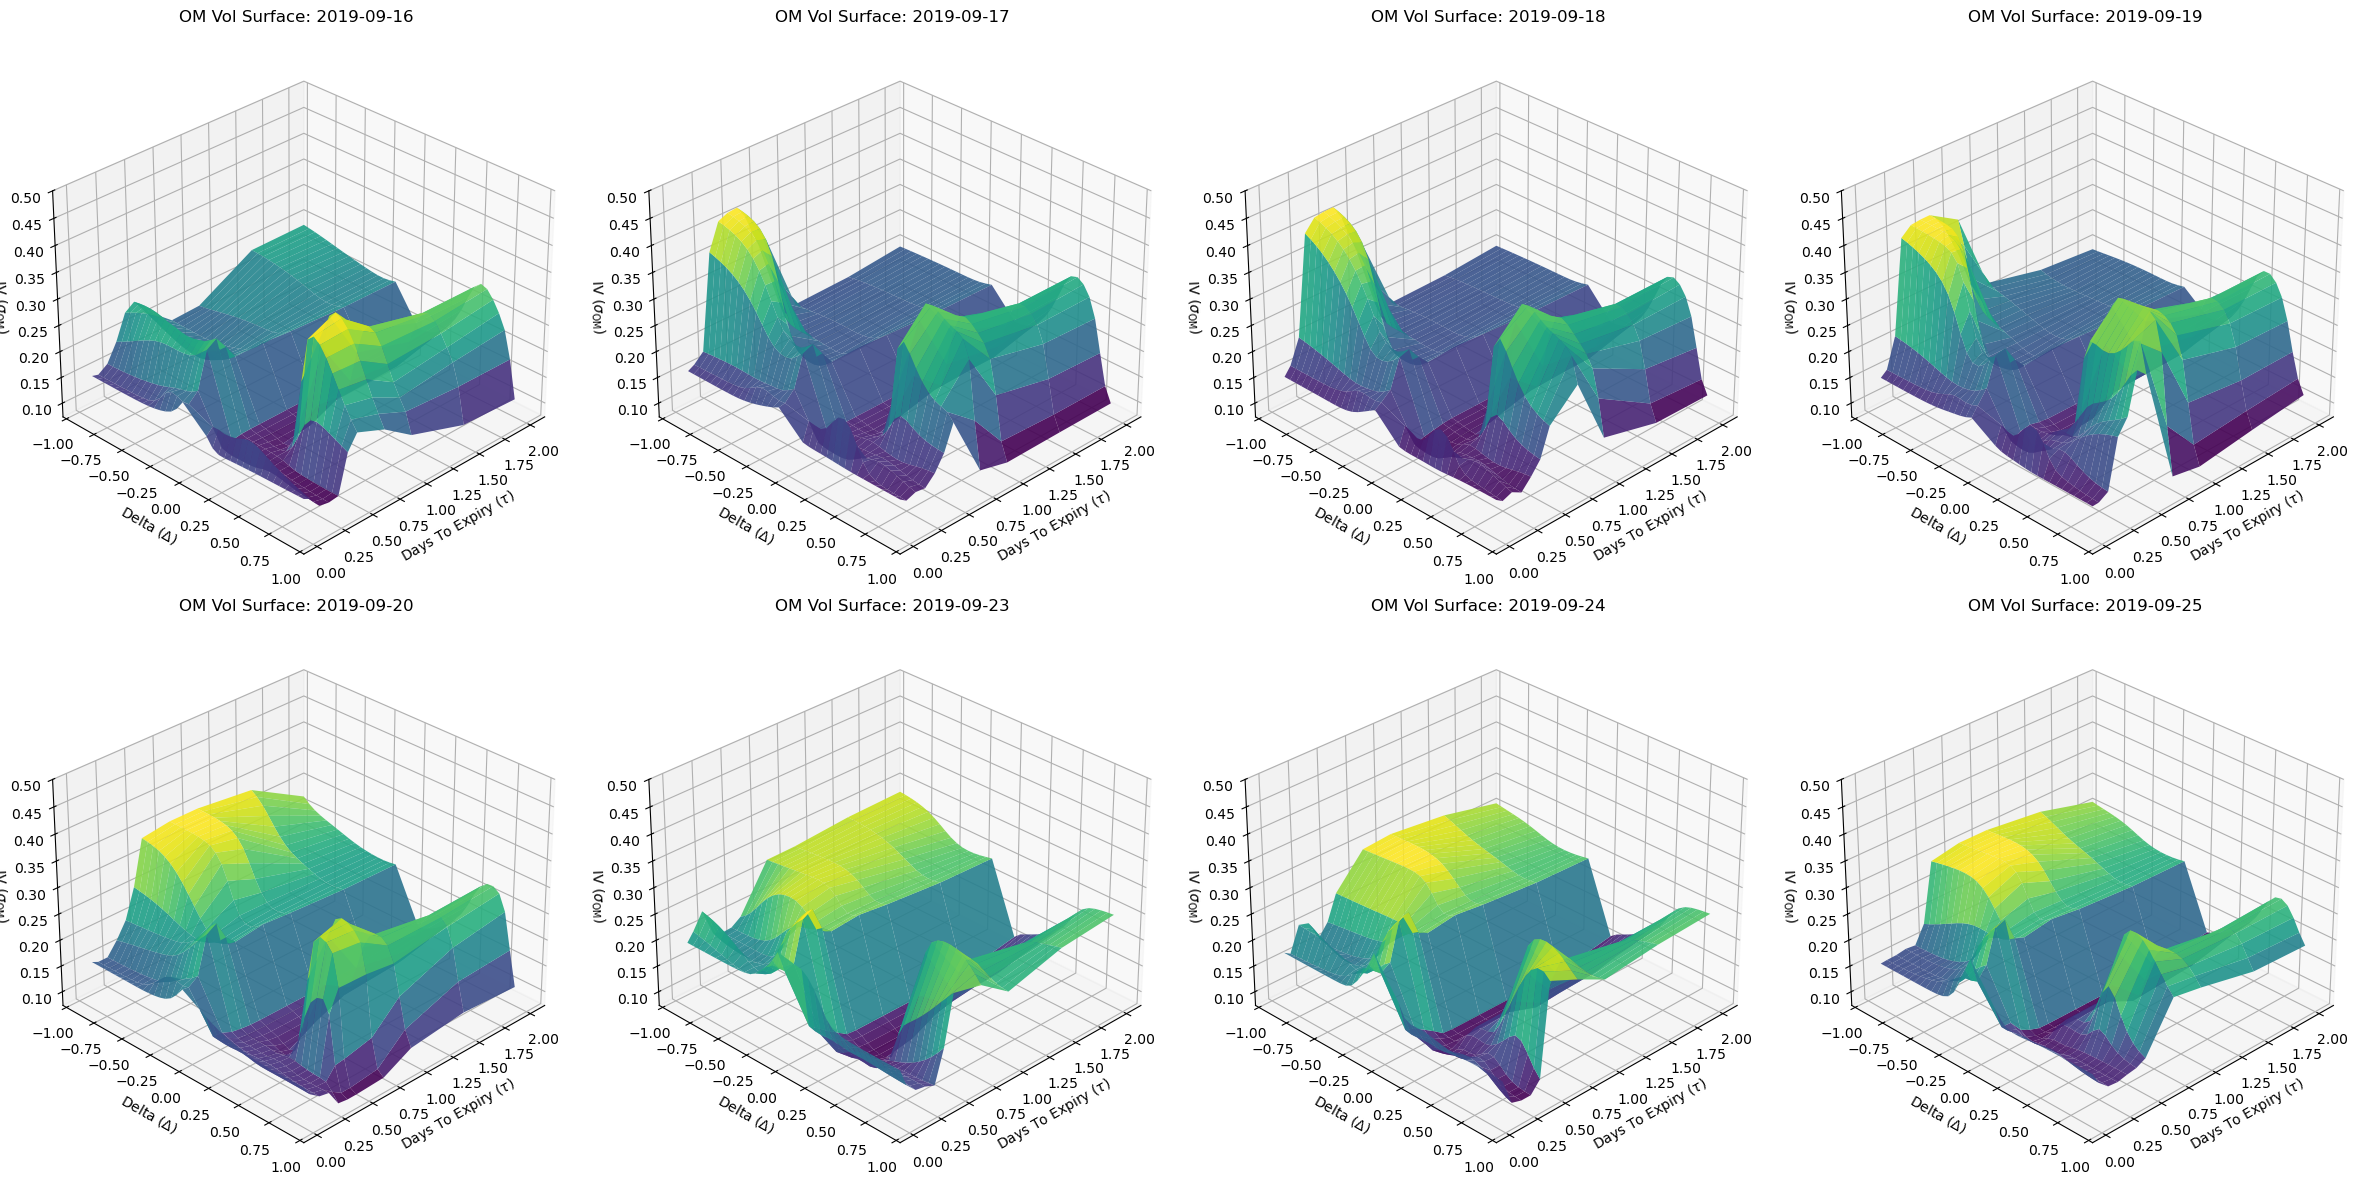

In [10]:
plot_om_surfaces(om_surface, start="2019-09-16", end="2019-09-25")
plt.show()

## Legendre projection coefficients

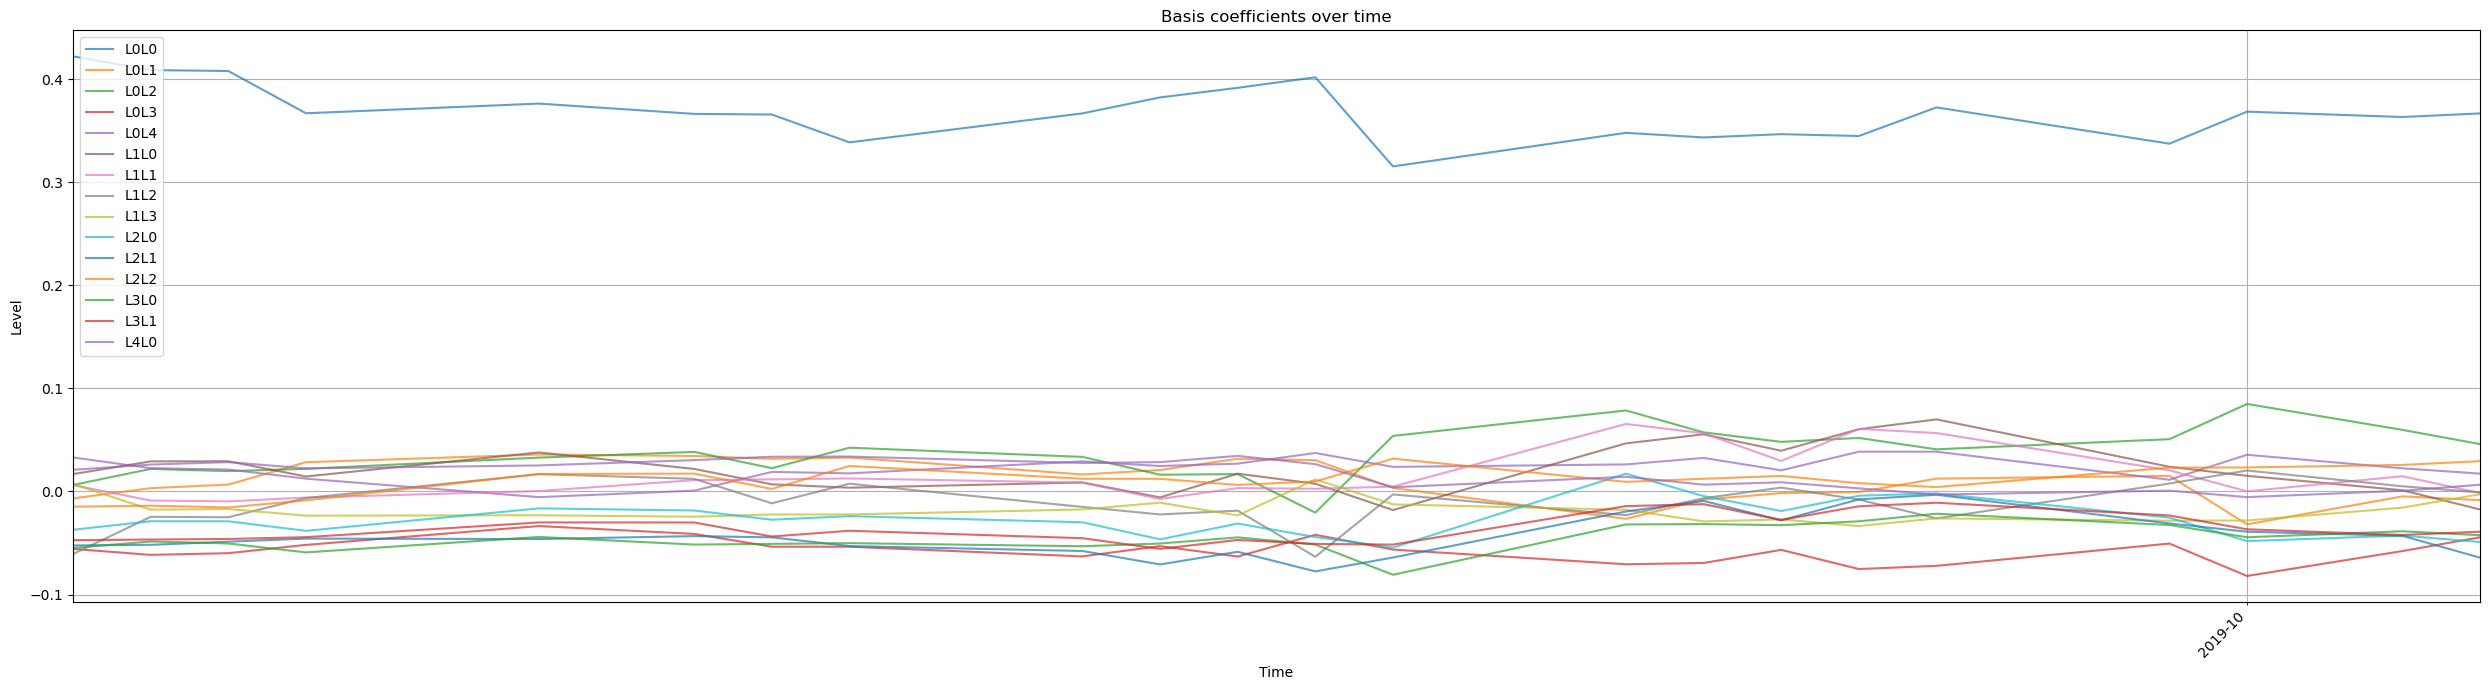

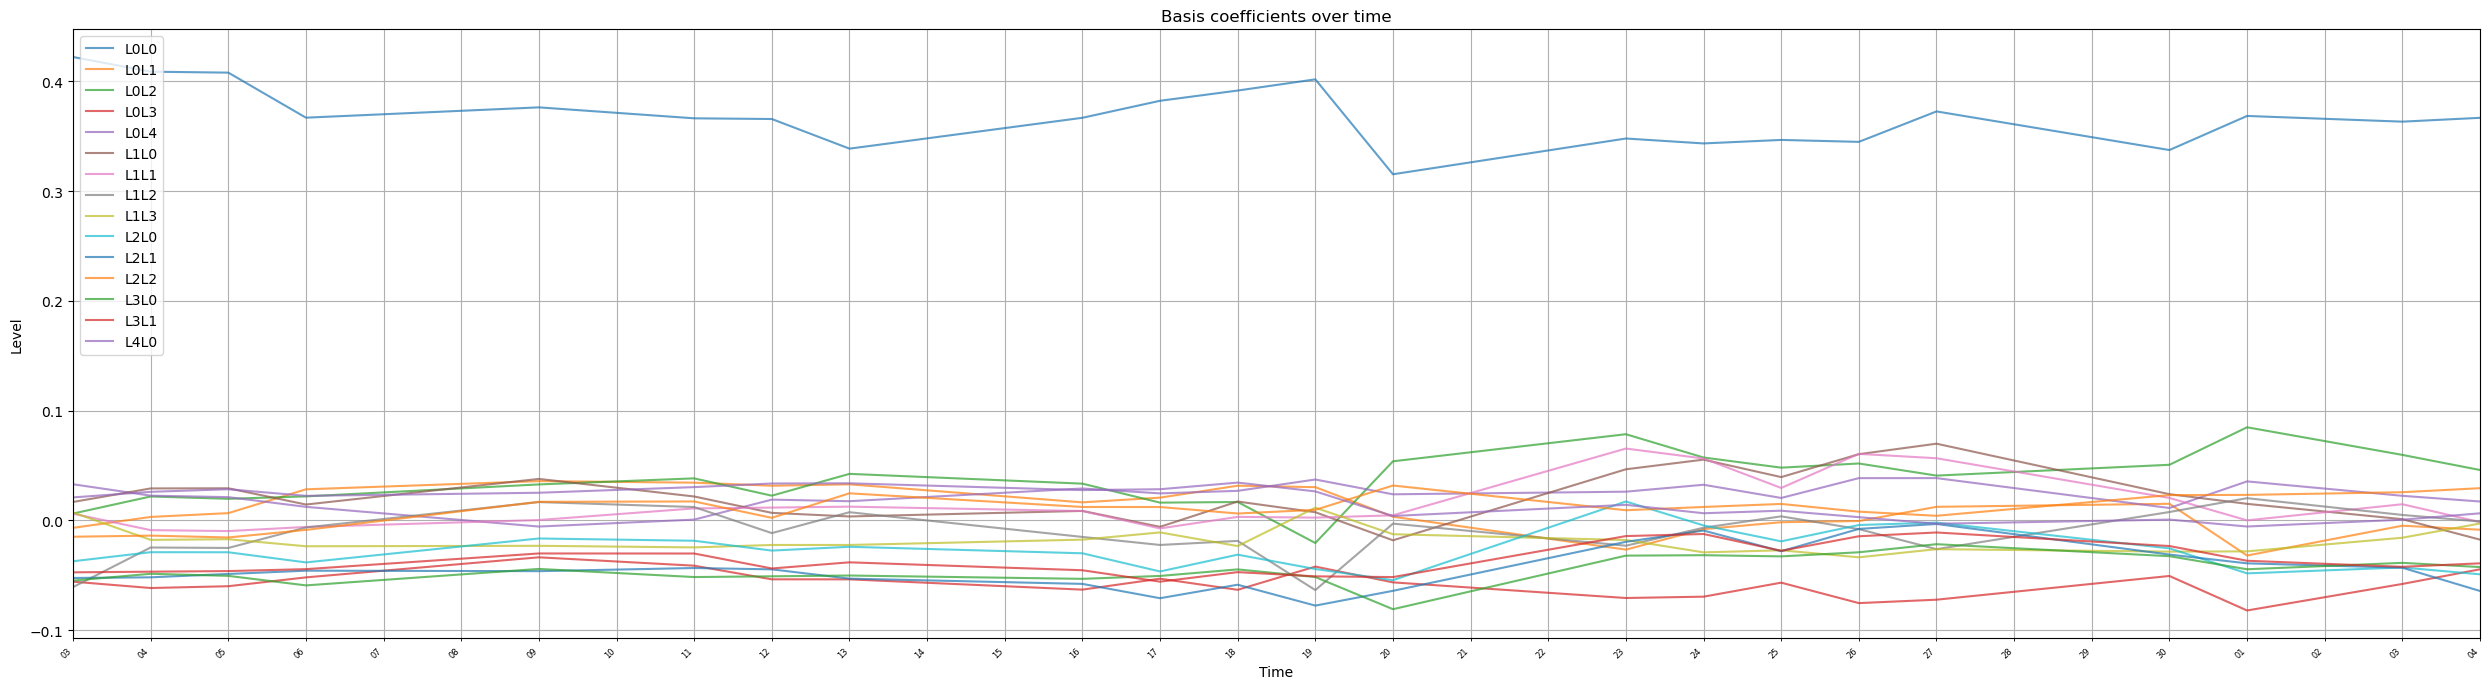

In [11]:
legendre_artefact_ce = "./funvol/legendre/artefacts/2026-09-16_22-11-17_legendre-coeffs-ce.csv"
coeffs_ce = pd.read_csv(legendre_artefact_ce, parse_dates=[0], index_col=[0])

plot_projection_coeffs(coeffs_ce)
plt.show()

plot_projection_coeffs(coeffs_ce.loc["2019-09-01":], daily_ticks=True)
plt.show()

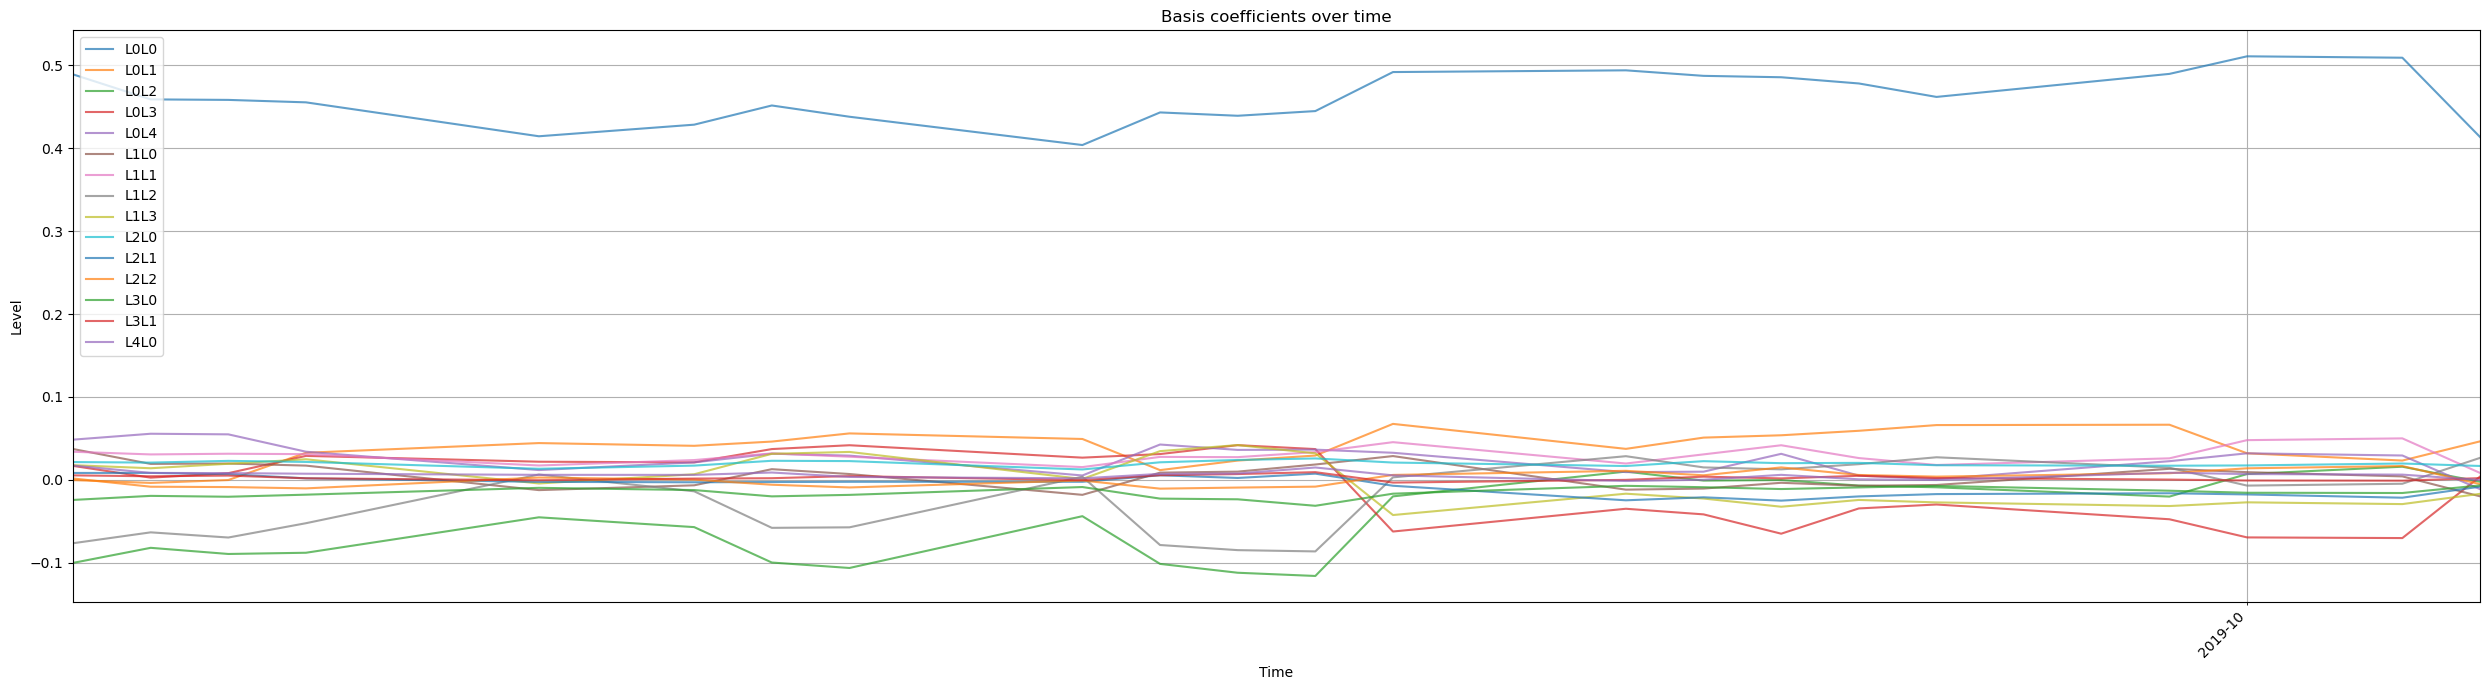

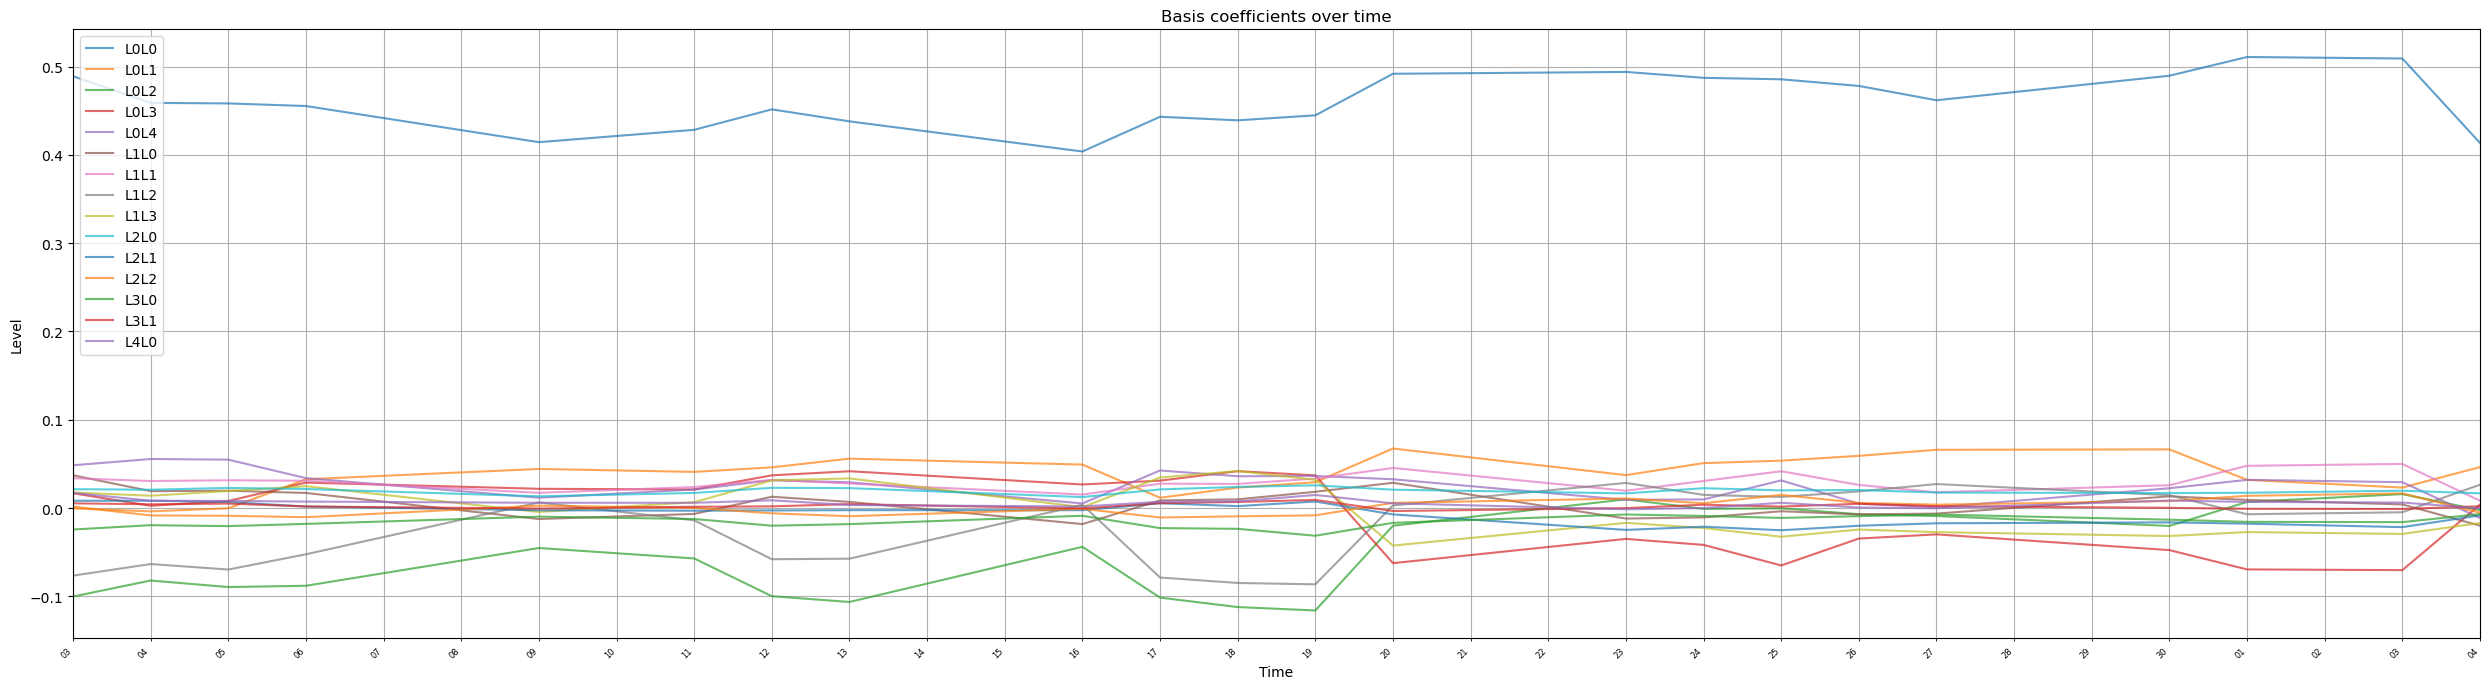

In [12]:
legendre_artefact_pe = "./funvol/legendre/artefacts/2026-09-16_22-11-17_legendre-coeffs-pe.csv"
coeffs_pe = pd.read_csv(legendre_artefact_pe, parse_dates=[0], index_col=[0])

plot_projection_coeffs(coeffs_pe)
plt.show()

plot_projection_coeffs(coeffs_pe.loc["2019-09-01":], daily_ticks=True)
plt.show()

## VIFs

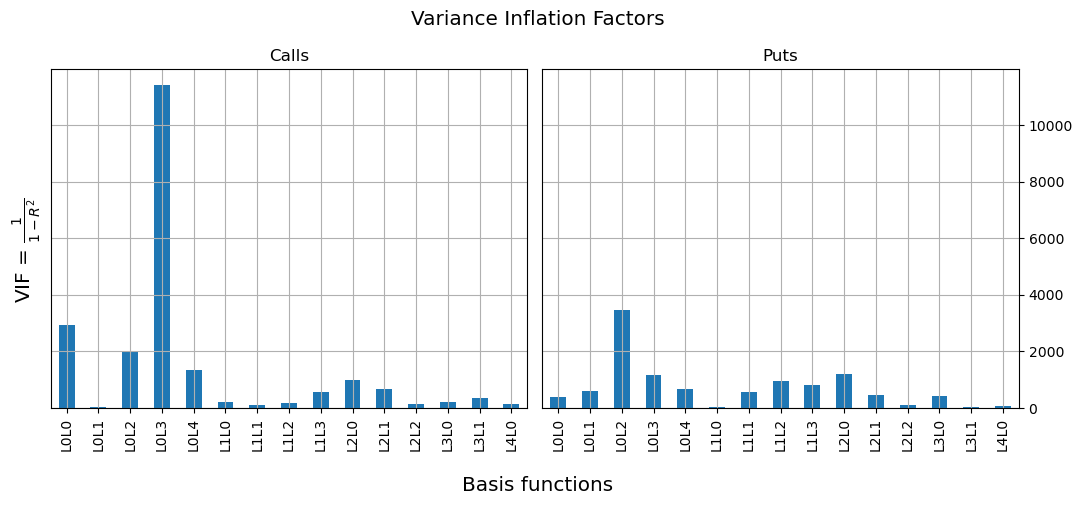

In [13]:
plot_vifs(
    dataframes = {
        "Calls": coeffs_ce,
        "Puts": coeffs_pe
    }
)

plt.show()

## FPCA

In [14]:
def adf_test(
        df: pd.DataFrame,
        maxlag: int=5,
        reg: Literal['c', 't', "ct"]='c'
    ) -> None:
    if reg not in ['c', 't', "ct"]:
        raise ValueError(
            f"{datetime.now()}: Invalid `reg` argument `{reg}`. Expected one "
            f"of `c`, `t`, or `ct`."
        )

    logger.info(f"{datetime.now()}: *** ADF TESTS ***")
    for c in df.columns:
        adf = sm.tsa.adfuller(x=df[c], maxlag=maxlag, regression=reg)
        logger.info(
            f"{datetime.now()}: {c}: adf={adf[0]:.4f}, p={adf[1]:.4f}"
        )

In [15]:
def pacf_lag1(df: pd.DataFrame) -> None:
    logger.info(f"{datetime.now()}: *** PACF LAG 1 COEFFS ***")
    for c in df.columns:
        ar1= sm.tsa.pacf(df[c])[1]
        logger.info(f"{datetime.now()}: {c}: ar1={ar1:.4f}")

### Eigensurfaces

In [16]:
pc_ce_artefact = "./funvol/fpca/artefacts/2026-09-17_11-33-34_princomps_ce.npy"
princomps_ce = np.load(pc_ce_artefact, allow_pickle=True)

eig_ce_artefact = "./funvol/fpca/artefacts/2026-09-17_11-33-34_eigsurfs_ce.npy"
eigenvars_ce = np.load(eig_ce_artefact, allow_pickle=True)

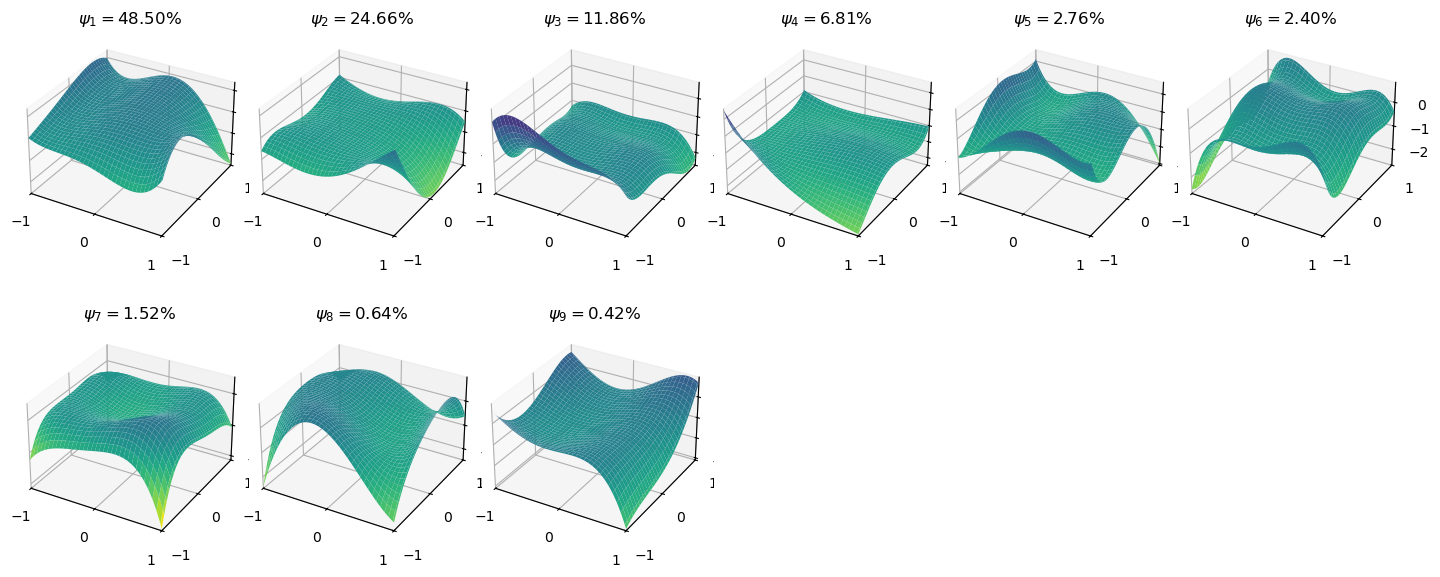

In [17]:
plot_eigensurfaces(princomps_ce, eigenvars_ce)
plt.show()

In [18]:
pc_pe_artefact = "./funvol/fpca/artefacts/2026-09-17_11-33-34_princomps_pe.npy"
princomps_pe = np.load(pc_pe_artefact, allow_pickle=True)

eig_pe_artefact = "./funvol/fpca/artefacts/2026-09-17_11-33-34_eigsurfs_pe.npy"
eigenvars_pe = np.load(eig_pe_artefact, allow_pickle=True)

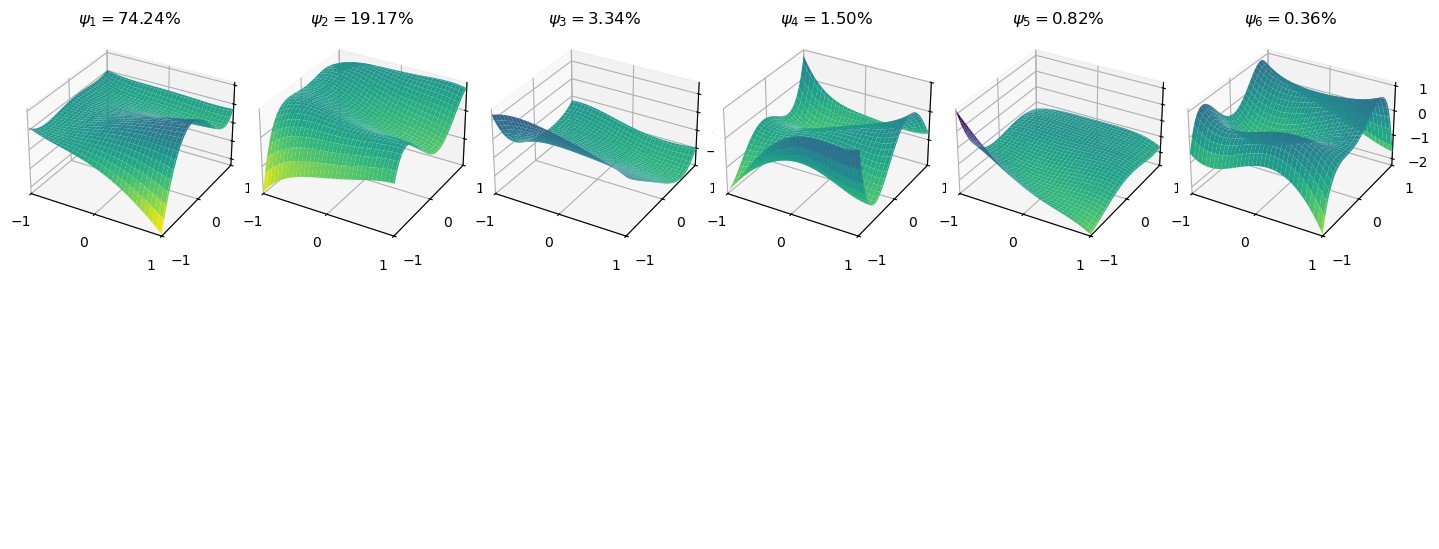

In [19]:
plot_eigensurfaces(princomps_pe, eigenvars_pe)
plt.show()

### FPCCs

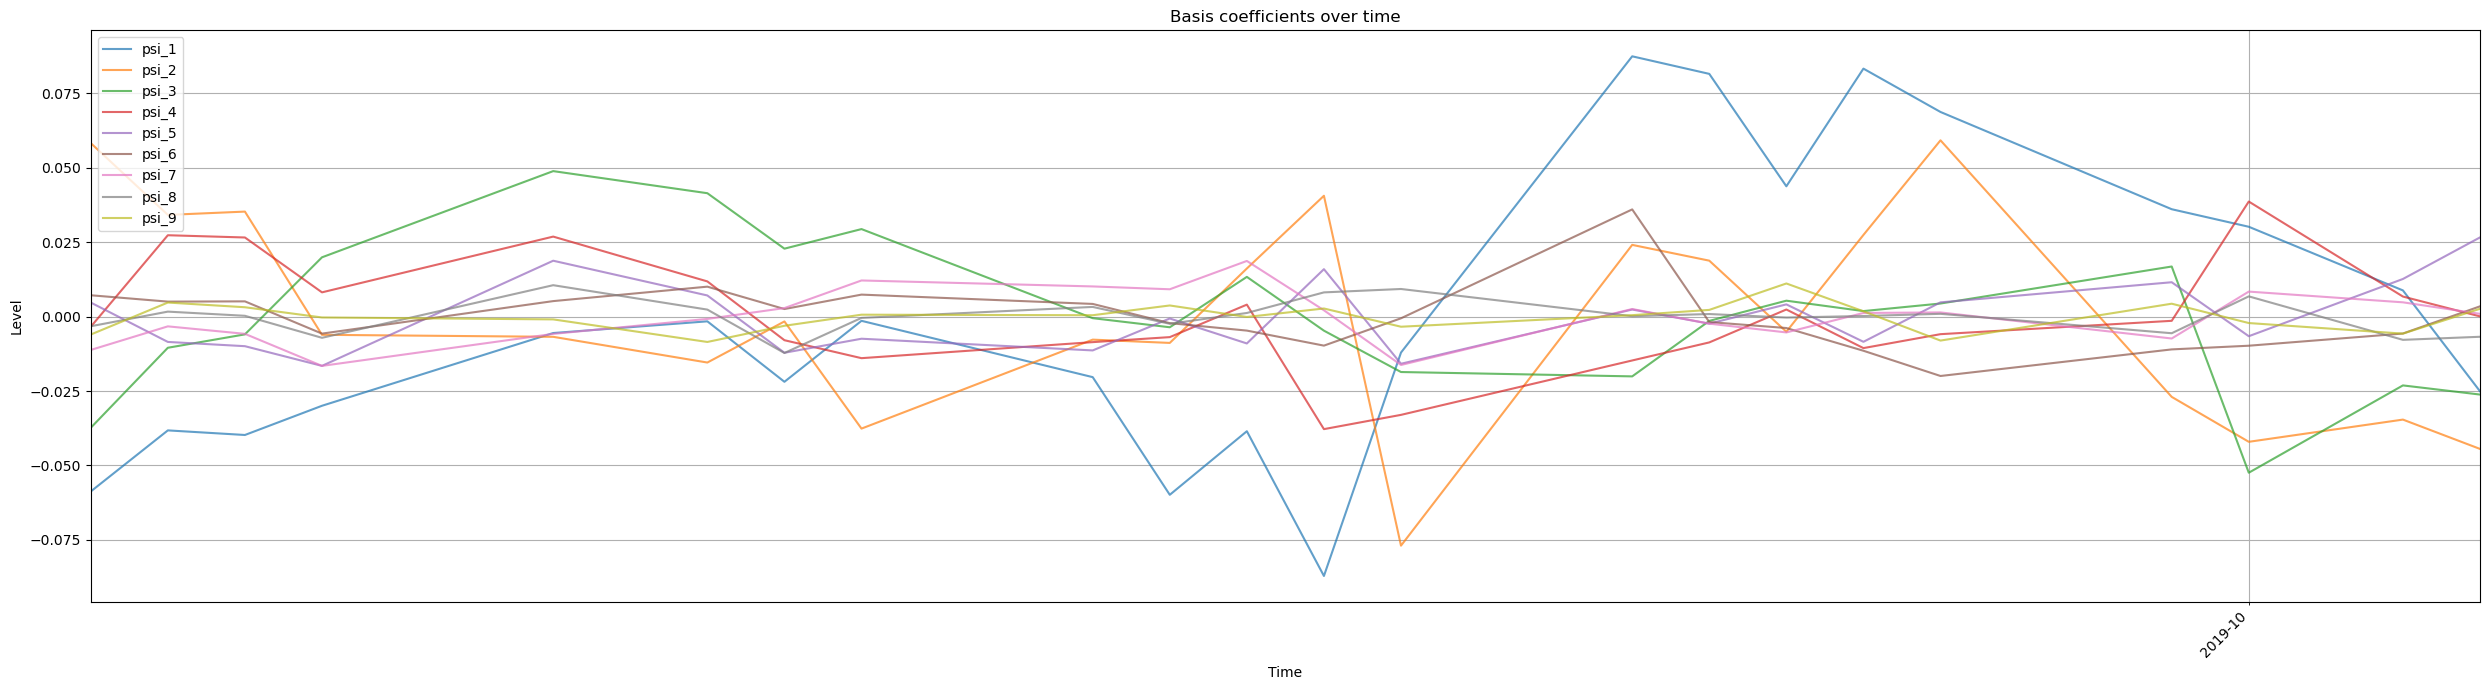

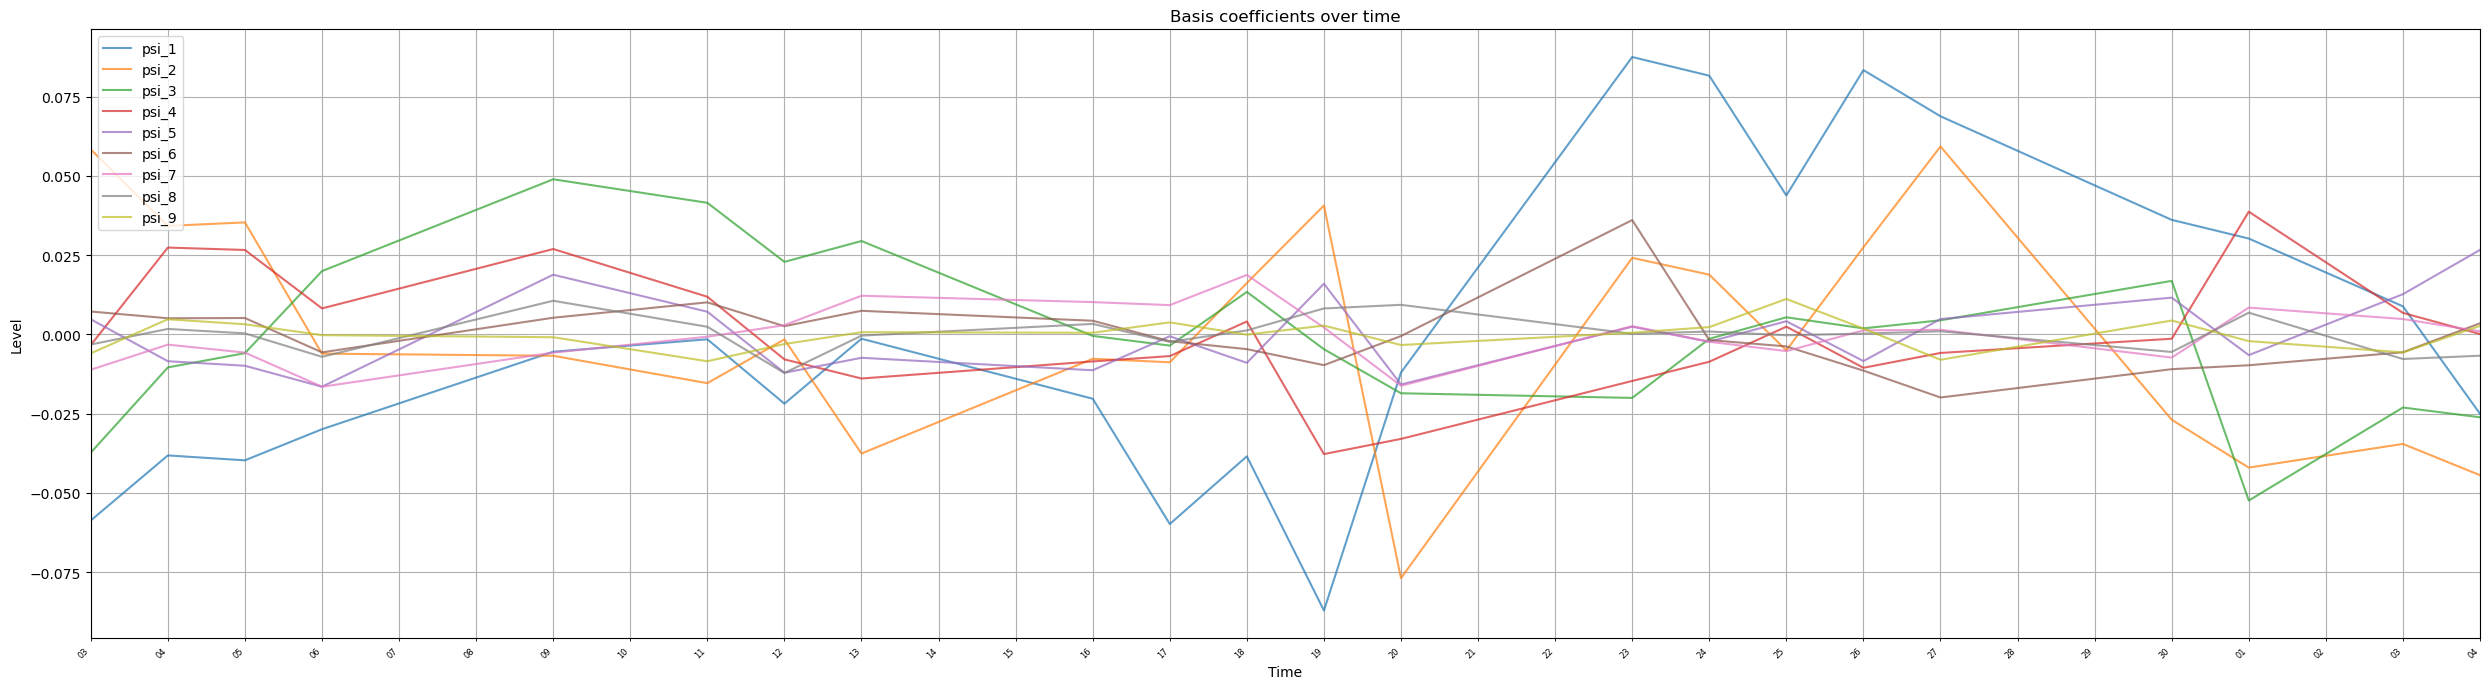

In [20]:
neural_ce_artefact = "./funvol/fpca/artefacts/2026-09-17_11-33-34_neural_ce.csv"
neural_ce = pd.read_csv(neural_ce_artefact, parse_dates=[0], index_col=[0])

plot_projection_coeffs(neural_ce)
plt.show()

plot_projection_coeffs(neural_ce.loc["2019-09-01":], daily_ticks=True)
plt.show()

In [21]:
adf_test(neural_ce)

INFO:__main__:2026-10-01 04:58:53.806362: *** ADF TESTS ***
INFO:__main__:2026-10-01 04:58:53.813416: psi_1: adf=-1.9554, p=0.3065
INFO:__main__:2026-10-01 04:58:53.817852: psi_2: adf=-3.8781, p=0.0022
INFO:__main__:2026-10-01 04:58:53.823316: psi_3: adf=-2.5437, p=0.1052
INFO:__main__:2026-10-01 04:58:53.828749: psi_4: adf=-2.5889, p=0.0953
INFO:__main__:2026-10-01 04:58:53.833515: psi_5: adf=-4.0793, p=0.0010
INFO:__main__:2026-10-01 04:58:53.839532: psi_6: adf=-3.2669, p=0.0164
INFO:__main__:2026-10-01 04:58:53.844583: psi_7: adf=-3.0509, p=0.0304
INFO:__main__:2026-10-01 04:58:53.849745: psi_8: adf=-4.5871, p=0.0001
INFO:__main__:2026-10-01 04:58:53.855474: psi_9: adf=-4.5822, p=0.0001


In [22]:
pacf_lag1(neural_ce)

INFO:__main__:2026-10-01 04:59:06.298559: *** PACF LAG 1 COEFFS ***
INFO:__main__:2026-10-01 04:59:06.320659: psi_1: ar1=0.7221
INFO:__main__:2026-10-01 04:59:06.324380: psi_2: ar1=0.1381
INFO:__main__:2026-10-01 04:59:06.326458: psi_3: ar1=0.5228
INFO:__main__:2026-10-01 04:59:06.329108: psi_4: ar1=0.5021
INFO:__main__:2026-10-01 04:59:06.332866: psi_5: ar1=-0.0566
INFO:__main__:2026-10-01 04:59:06.336367: psi_6: ar1=0.3016
INFO:__main__:2026-10-01 04:59:06.339012: psi_7: ar1=0.3923
INFO:__main__:2026-10-01 04:59:06.342312: psi_8: ar1=-0.0756
INFO:__main__:2026-10-01 04:59:06.344528: psi_9: ar1=-0.0160


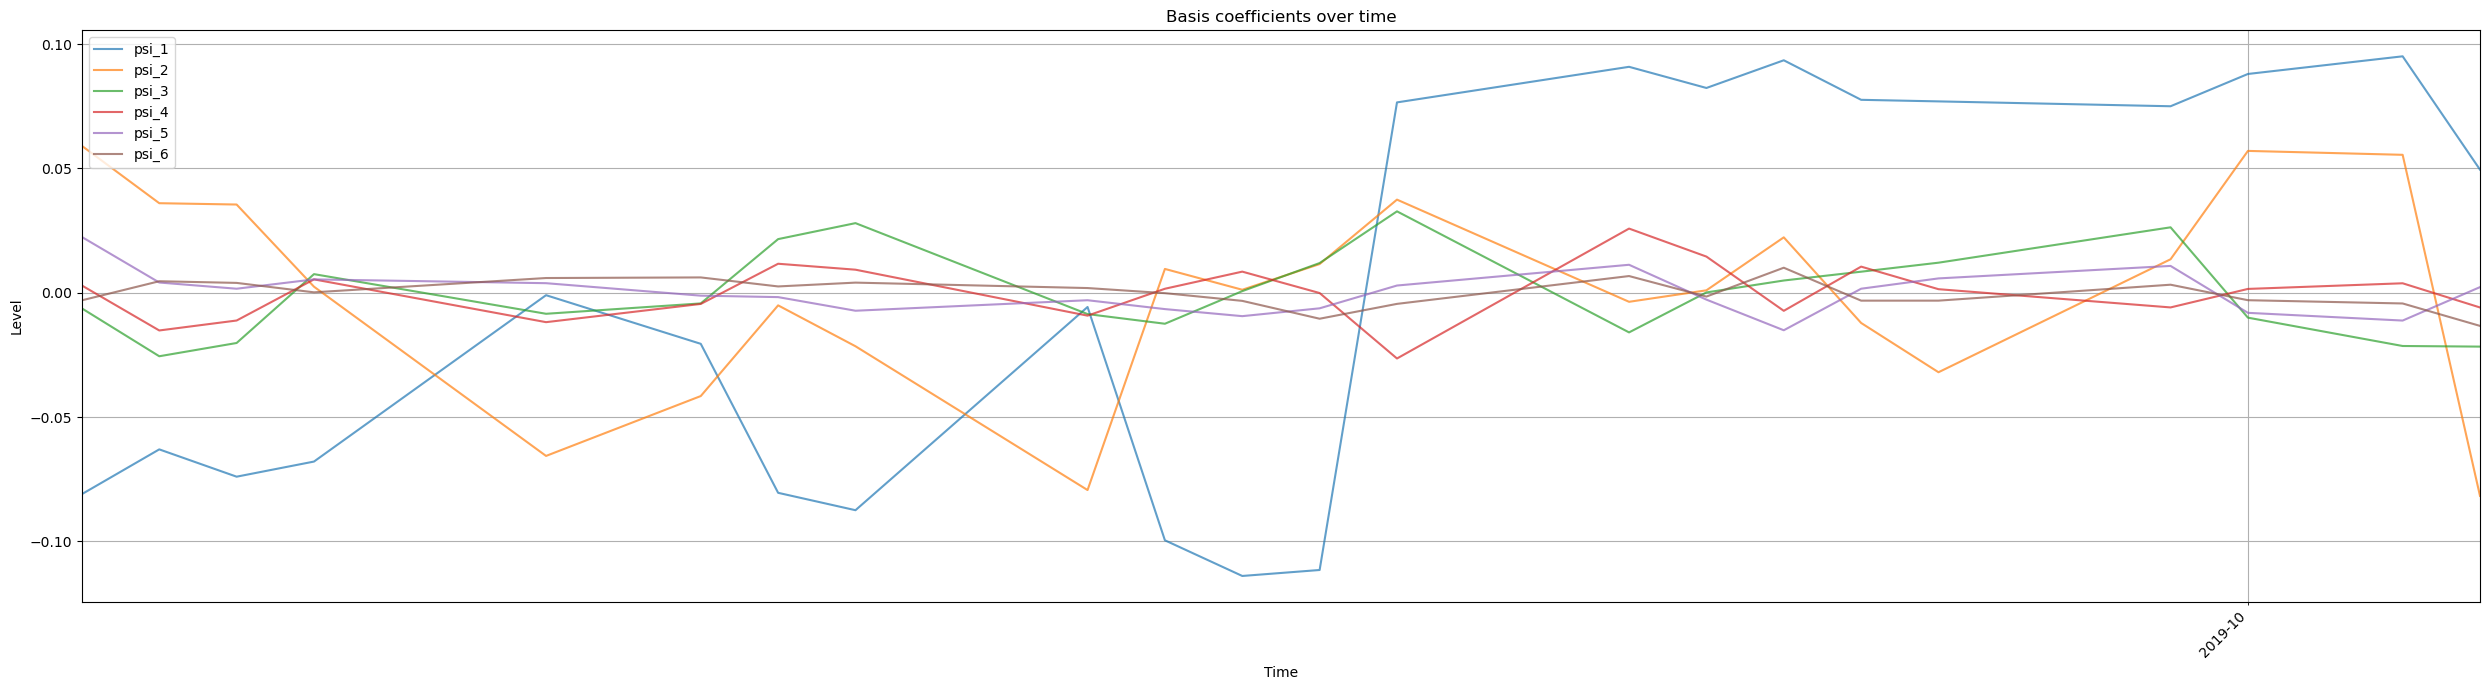

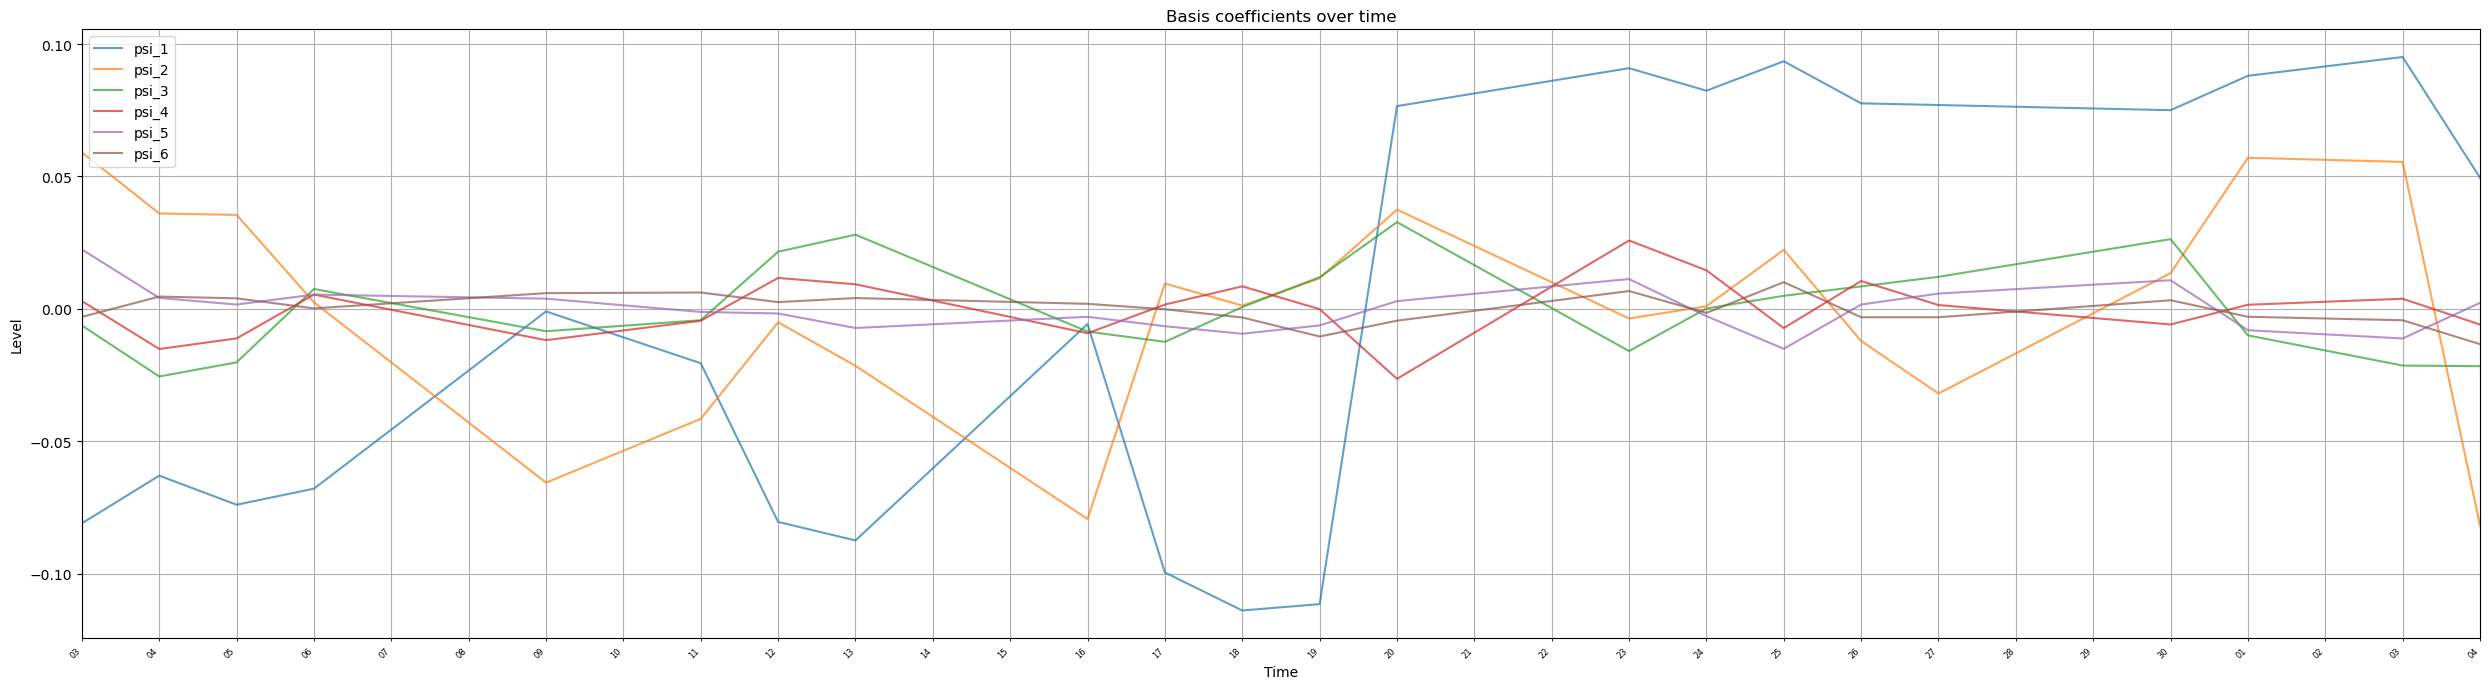

In [23]:
neural_pe_artefact = "./funvol/fpca/artefacts/2026-09-17_11-33-34_neural_pe.csv"
neural_pe = pd.read_csv(neural_pe_artefact, parse_dates=[0], index_col=[0])

plot_projection_coeffs(neural_pe)
plt.show()

plot_projection_coeffs(neural_pe.loc["2019-09-01":], daily_ticks=True)
plt.show()

In [24]:
adf_test(neural_pe)

INFO:__main__:2026-10-01 05:00:17.001213: psi_1: adf=-1.7015, p=0.4303
INFO:__main__:2026-10-01 05:00:17.006766: psi_2: adf=-3.1968, p=0.0202
INFO:__main__:2026-10-01 05:00:17.011389: psi_3: adf=-2.2959, p=0.1733
INFO:__main__:2026-10-01 05:00:17.019437: psi_4: adf=-5.3309, p=0.0000
INFO:__main__:2026-10-01 05:00:17.025595: psi_5: adf=-4.0390, p=0.0012
INFO:__main__:2026-10-01 05:00:17.030399: psi_6: adf=-2.8199, p=0.0555


In [25]:
pacf_lag1(neural_pe)

INFO:__main__:2026-10-01 05:00:17.114574: psi_1: ar1=0.7722
INFO:__main__:2026-10-01 05:00:17.120070: psi_2: ar1=0.2001
INFO:__main__:2026-10-01 05:00:17.124354: psi_3: ar1=0.2760
INFO:__main__:2026-10-01 05:00:17.126524: psi_4: ar1=-0.1829
INFO:__main__:2026-10-01 05:00:17.129126: psi_5: ar1=0.2414
INFO:__main__:2026-10-01 05:00:17.131974: psi_6: ar1=0.2035


## Price & detrending
Of the underlying asset price series

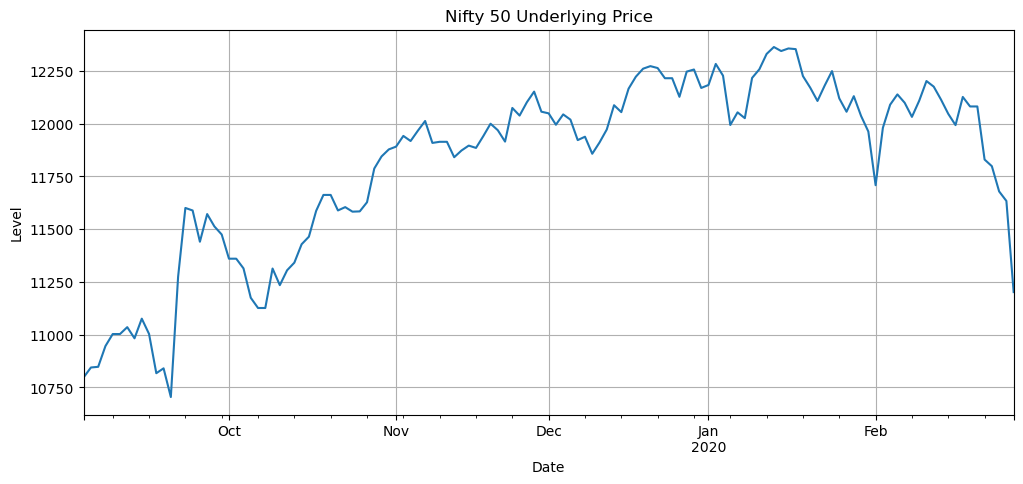

In [26]:
underlying_artefact = "./data/nifty-daily.csv"
nifty = load_underlying(underlying_artefact, freq='B')

ax = nifty.loc["2019-09-03":"2020-02-29"].plot(grid=True, figsize=(12, 5))
ax.set_title("Nifty 50 Underlying Price")
ax.set_ylabel("Level")
ax.set_xlabel("Date")

plt.show()

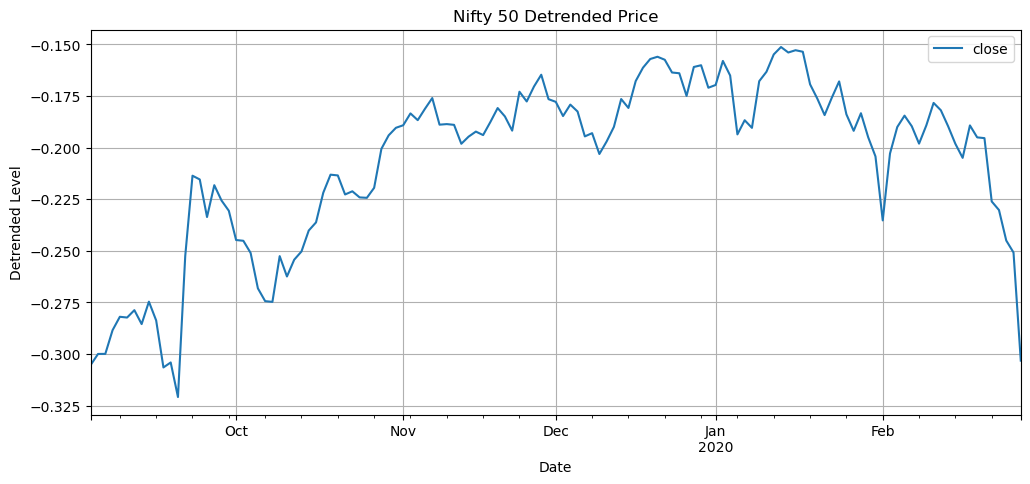

In [27]:
price_artefact = "./funvol/detrended_price/artefacts/2026-09-17_11-39-17_detrended_underlying_price.csv"

nifty_detrended = pd.read_csv(price_artefact, parse_dates=[0], index_col=[0])

ax = nifty_detrended.loc["2019-09-03":"2020-02-29"].plot(
    grid    = True,
    figsize = (12, 5)
)
ax.set_title("Nifty 50 Detrended Price")
ax.set_ylabel("Detrended Level")
ax.set_xlabel("Date")

plt.show()

## Analytics

In [28]:
def quasi_diff(
        data: pd.Series
    ) -> sm.regression.linear_model.RegressionResultsWrapper:
    demean = data - data.mean()
    shifted = demean.shift(1).dropna()
    reindex = demean.loc[shifted.index]

    mod = sm.OLS(endog=reindex, exog=shifted, hasconst=False)
    res = mod.fit()
    return res

In [29]:
# This is probably an easier way to gauge whether or not jumps are warranted.
# Gatheral points out in his book that some SPX returns are over 17 standard
# deviations away, and the Gaussian has a vanishingly small probability of
# generating such occurrences. We can just do the same thing.

def deviations_away(
        x: float,
        dist: _continuous_distns,
        distparams: tuple
    ) -> float:
    loc = distparams[-2]  # not always correct!

    proba = (
          dist.cdf(loc-abs(x), *distparams)
        + dist.sf(loc+abs(x), *distparams)
    )
    return proba

In [30]:
def compute_deviations_away(
        df: pd.DataFrame,
        p: Iterable,
        dist: _continuous_distns
    ) -> pd.Series:
    diff = df.diff().dropna()
    diff_mean = diff.mean()
    diff_sdev = diff.std()
    z = diff.sub(diff_mean).div(diff_sdev)

    params = dist.fit(z)

    ret = (
        z
        .max()
        .apply(deviations_away, dist=dist, distparams=params)
        .round(12)
    )

    return ret

In [32]:
def lbox_test(df: pd.DataFrame, lags: Iterable=[1, 5, 10]) -> pd.DataFrame:
    ress = []
    logger.info(f"{datetime.now()}: *** LJUNG-BOX TESTS ***")
    for col in df.columns:
        res = acorr_ljungbox(df[col], lags=lags)
        res = (
            res
            .assign(
                combined = list(
                    zip(res["lb_stat"].round(4), res["lb_pvalue"].round(4))
                ),
                fpcc = col
            )
            .reset_index(names=["lag"])
        )
        ress.append(res)

    ress = pd.concat(ress)
    return ress.pivot(values="combined", index="fpcc", columns="lag")

#### Deviations Away
How many deviations away, with a given distribution, is the maximum empirical value of an FPCC?

In [35]:
dists = {"norm": norm, "studentt": t, "nig": norminvgauss}

for wing, _df in zip(["calls", "puts"], [neural_ce, neural_pe]):
    _res = []

    for name, dist in dists.items():
        max_devs = compute_deviations_away(
            df   = _df,
            p    = np.arange(0.10, 0.99, 0.11),
            dist = dist
        )
        _res.append(max_devs.rename(dist.name))

    logger.info(f"{datetime.now()}: *** MAXVAL DEVIATIONS AWAY ***")
    print(f"{wing}:")
    display(pd.DataFrame(_res).round(4))

INFO:__main__:2026-10-01 05:06:32.137784: *** MAXVAL DEVIATIONS AWAY ***


calls:


,psi_1,psi_2,psi_3,psi_4,psi_5,psi_6,psi_7,psi_8,psi_9
norm,0.0075,0.0152,0.2007,0.0358,0.0338,0.0050,0.0559,0.0298,0.0610
t,0.0147,0.0231,0.1820,0.0421,0.0403,0.0116,0.0594,0.0368,0.0636
norminvgauss,0.0151,0.0239,0.1819,0.0434,0.0416,0.0118,0.0609,0.0380,0.0652


INFO:__main__:2026-10-01 05:06:32.256252: *** MAXVAL DEVIATIONS AWAY ***


puts:


,psi_1,psi_2,psi_3,psi_4,psi_5,psi_6
norm,0.0008,0.0413,0.1589,0.0026,0.0571,0.0631
t,0.0057,0.0477,0.1421,0.0095,0.0606,0.0654
norminvgauss,0.0055,0.0497,0.1434,0.0097,0.0628,0.0677


#### Ljung-Box Tests
LB results reported as (LB statistic, p-value).

In [34]:
for wing, _df in zip(["calls", "puts"], [neural_ce, neural_pe]):
    print(f"{wing}:")
    display( lbox_test(_df).T )

INFO:__main__:2026-10-01 05:05:24.895906: *** LJUNG-BOX TESTS ***


calls:


fpcc,psi_1,psi_2,psi_3,psi_4,psi_5,psi_6,psi_7,psi_8,psi_9
lag,,,,,,,,,
1,"(11.946, 0.0005)","(0.4371, 0.5085)","(6.2616, 0.0123)","(5.7758, 0.0162)","(0.0734, 0.7865)","(2.0839, 0.1489)","(3.5249, 0.0605)","(0.1309, 0.7175)","(0.0059, 0.939)"
5,"(18.4983, 0.0024)","(3.6411, 0.6022)","(10.5116, 0.062)","(7.8393, 0.1653)","(0.8621, 0.9729)","(4.7223, 0.4507)","(12.2487, 0.0315)","(6.2903, 0.279)","(2.9212, 0.7121)"
10,"(21.1972, 0.0198)","(5.3638, 0.8656)","(11.5041, 0.3196)","(25.9024, 0.0039)","(5.1252, 0.8827)","(9.2797, 0.5058)","(23.4855, 0.0091)","(10.1164, 0.4303)","(7.6008, 0.6678)"


INFO:__main__:2026-10-01 05:05:24.952145: *** LJUNG-BOX TESTS ***


puts:


fpcc,psi_1,psi_2,psi_3,psi_4,psi_5,psi_6
lag,,,,,,
1,"(13.6611, 0.0002)","(0.9168, 0.3383)","(1.745, 0.1865)","(0.7662, 0.3814)","(1.3351, 0.2479)","(0.9483, 0.3301)"
5,"(27.6739, 0.0)","(2.0433, 0.8431)","(4.2546, 0.5134)","(15.3079, 0.0091)","(5.9303, 0.3131)","(2.1059, 0.8343)"
10,"(32.0607, 0.0004)","(4.5367, 0.9199)","(6.3866, 0.7818)","(21.6653, 0.0169)","(11.1243, 0.3479)","(7.4792, 0.6796)"


#### QQ Plots

INFO:plots:2026-09-23 14:30:59.400136: psi_1: mean log-likelihood=1.8885, BIC=-73.2296
INFO:plots:2026-09-23 14:30:59.403930: psi_2: mean log-likelihood=1.7129, BIC=-65.8530
INFO:plots:2026-09-23 14:30:59.406472: psi_3: mean log-likelihood=2.3747, BIC=-93.6482
INFO:plots:2026-09-23 14:30:59.407956: psi_4: mean log-likelihood=2.5440, BIC=-100.7578
INFO:plots:2026-09-23 14:30:59.409905: psi_5: mean log-likelihood=2.7067, BIC=-107.5931
INFO:plots:2026-09-23 14:30:59.411682: psi_6: mean log-likelihood=2.9168, BIC=-116.4164
INFO:plots:2026-09-23 14:30:59.413416: psi_7: mean log-likelihood=3.2339, BIC=-129.7353
INFO:plots:2026-09-23 14:30:59.415150: psi_8: mean log-likelihood=3.3832, BIC=-136.0051
INFO:plots:2026-09-23 14:30:59.416643: psi_9: mean log-likelihood=3.6337, BIC=-146.5264


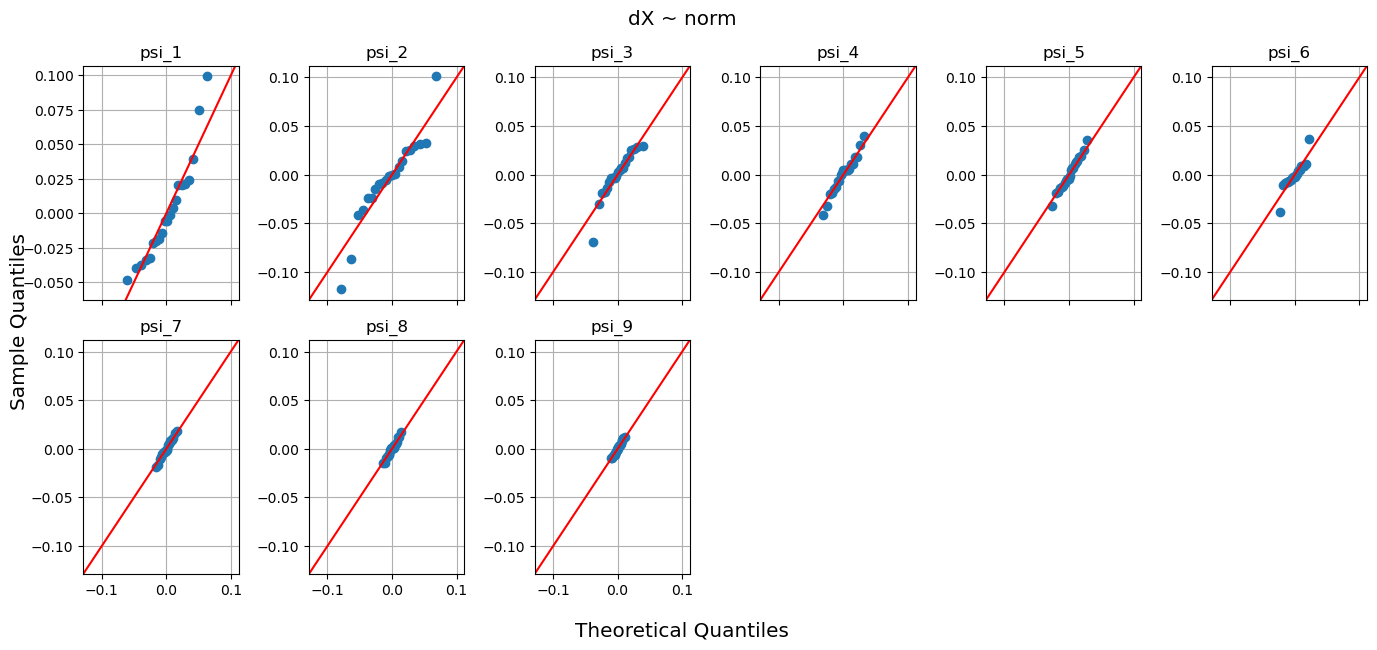

INFO:plots:2026-09-23 14:31:00.821875: psi_1: mean log-likelihood=1.9055, BIC=-70.8960
INFO:plots:2026-09-23 14:31:00.866708: psi_2: mean log-likelihood=1.7930, BIC=-66.1723
INFO:plots:2026-09-23 14:31:00.950425: psi_3: mean log-likelihood=2.4261, BIC=-92.7637
INFO:plots:2026-09-23 14:31:01.081093: psi_4: mean log-likelihood=2.5440, BIC=-97.7133
INFO:plots:2026-09-23 14:31:01.216418: psi_5: mean log-likelihood=2.7067, BIC=-104.5486
INFO:plots:2026-09-23 14:31:01.277577: psi_6: mean log-likelihood=3.0873, BIC=-120.5343
INFO:plots:2026-09-23 14:31:01.408275: psi_7: mean log-likelihood=3.2339, BIC=-126.6907
INFO:plots:2026-09-23 14:31:01.538444: psi_8: mean log-likelihood=3.3832, BIC=-132.9606
INFO:plots:2026-09-23 14:31:01.660825: psi_9: mean log-likelihood=3.6337, BIC=-143.4818


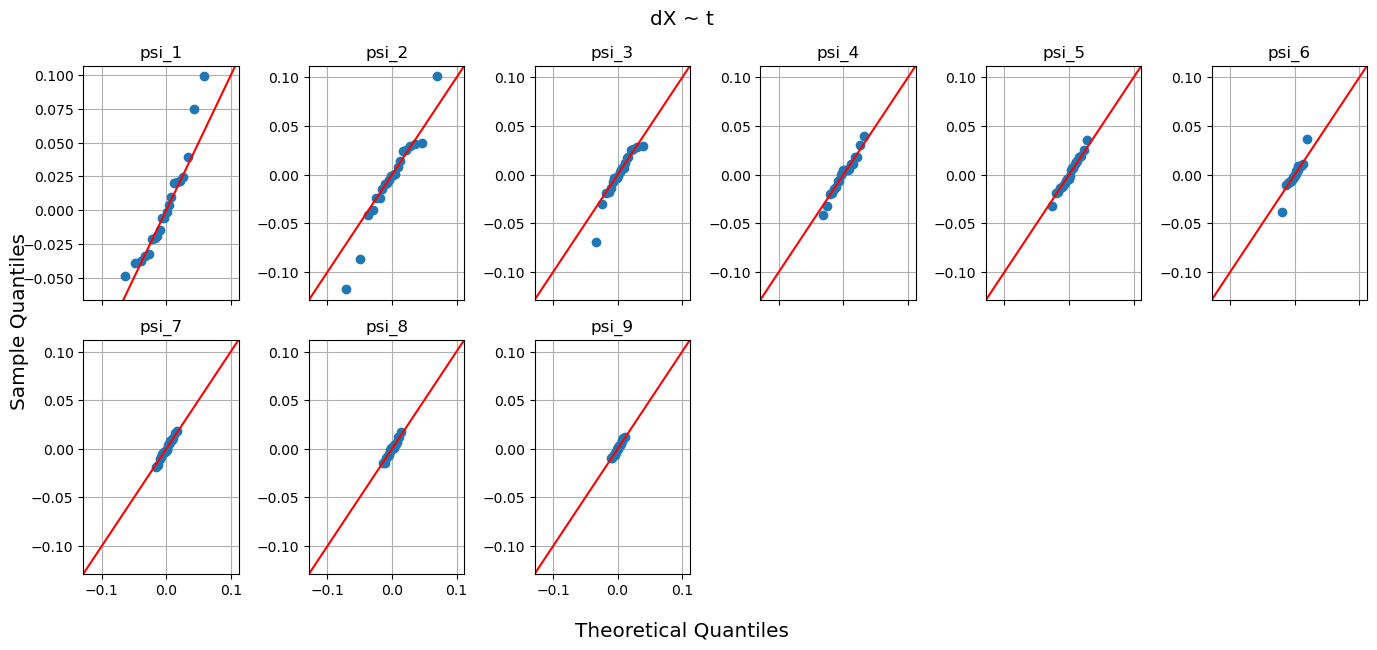

INFO:plots:2026-09-23 14:31:03.151746: psi_1: mean log-likelihood=2.0145, BIC=-72.4309
INFO:plots:2026-09-23 14:31:03.186009: psi_2: mean log-likelihood=1.8074, BIC=-63.7330
INFO:plots:2026-09-23 14:31:03.277949: psi_3: mean log-likelihood=2.4930, BIC=-92.5263
INFO:plots:2026-09-23 14:31:03.328056: psi_4: mean log-likelihood=2.5458, BIC=-94.7466
INFO:plots:2026-09-23 14:31:03.444583: psi_5: mean log-likelihood=2.7066, BIC=-101.5006
INFO:plots:2026-09-23 14:31:03.476786: psi_6: mean log-likelihood=3.0857, BIC=-117.4221
INFO:plots:2026-09-23 14:31:03.566439: psi_7: mean log-likelihood=3.2350, BIC=-123.6925
INFO:plots:2026-09-23 14:31:03.678913: psi_8: mean log-likelihood=3.3855, BIC=-130.0128
INFO:plots:2026-09-23 14:31:03.772037: psi_9: mean log-likelihood=3.6336, BIC=-140.4336
/home/rahuls/miniforge3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:5541: RuntimeWarning: overflow encountered in scalar multiply
  return fac1 * sc.k1e(a * sq) * np.exp(b*x - a*sq + gamma) / s

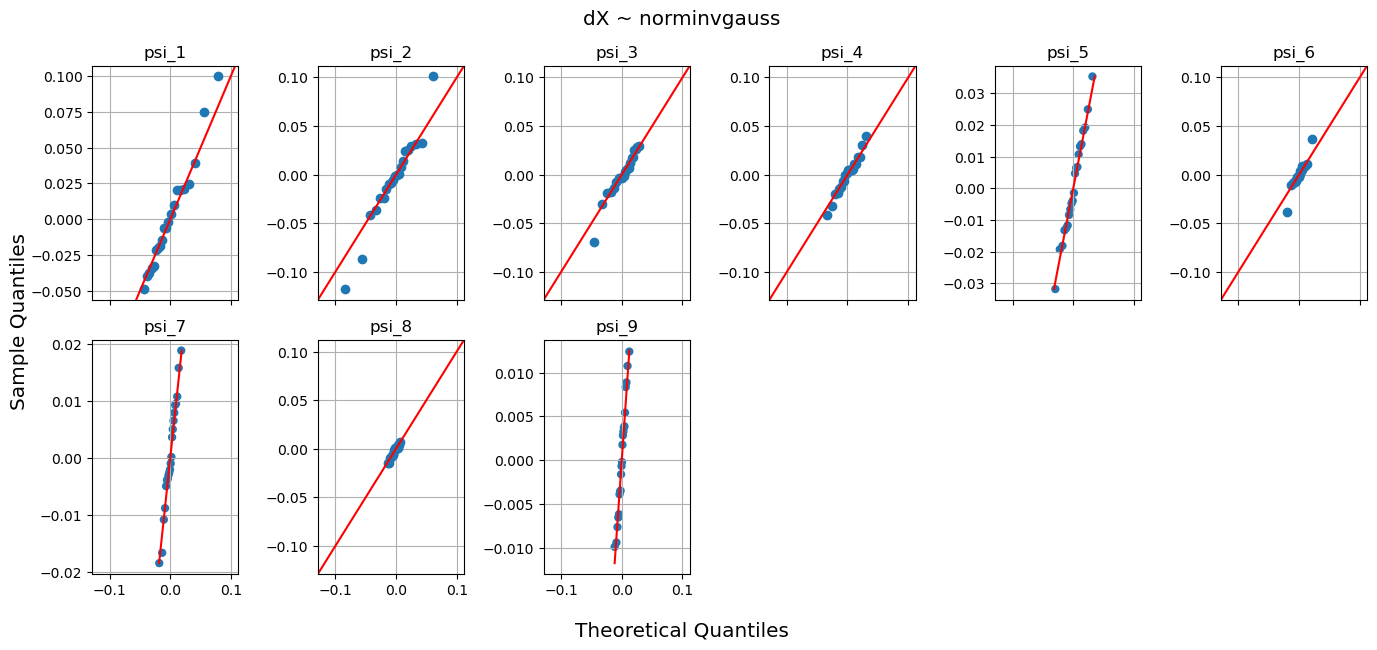

In [49]:
for dist in [norm, t, norminvgauss]:
    distribution_diagnostics(neural_ce, dist, qq=True)
    plt.show()

INFO:plots:2026-09-23 14:31:15.903877: psi_1: mean log-likelihood=1.4922, BIC=-56.5837
INFO:plots:2026-09-23 14:31:15.907081: psi_2: mean log-likelihood=1.6417, BIC=-62.8607
INFO:plots:2026-09-23 14:31:15.909135: psi_3: mean log-likelihood=2.4843, BIC=-98.2514
INFO:plots:2026-09-23 14:31:15.911012: psi_4: mean log-likelihood=2.6258, BIC=-104.1943
INFO:plots:2026-09-23 14:31:15.912951: psi_5: mean log-likelihood=3.2600, BIC=-130.8319
INFO:plots:2026-09-23 14:31:15.916537: psi_6: mean log-likelihood=3.6158, BIC=-145.7747


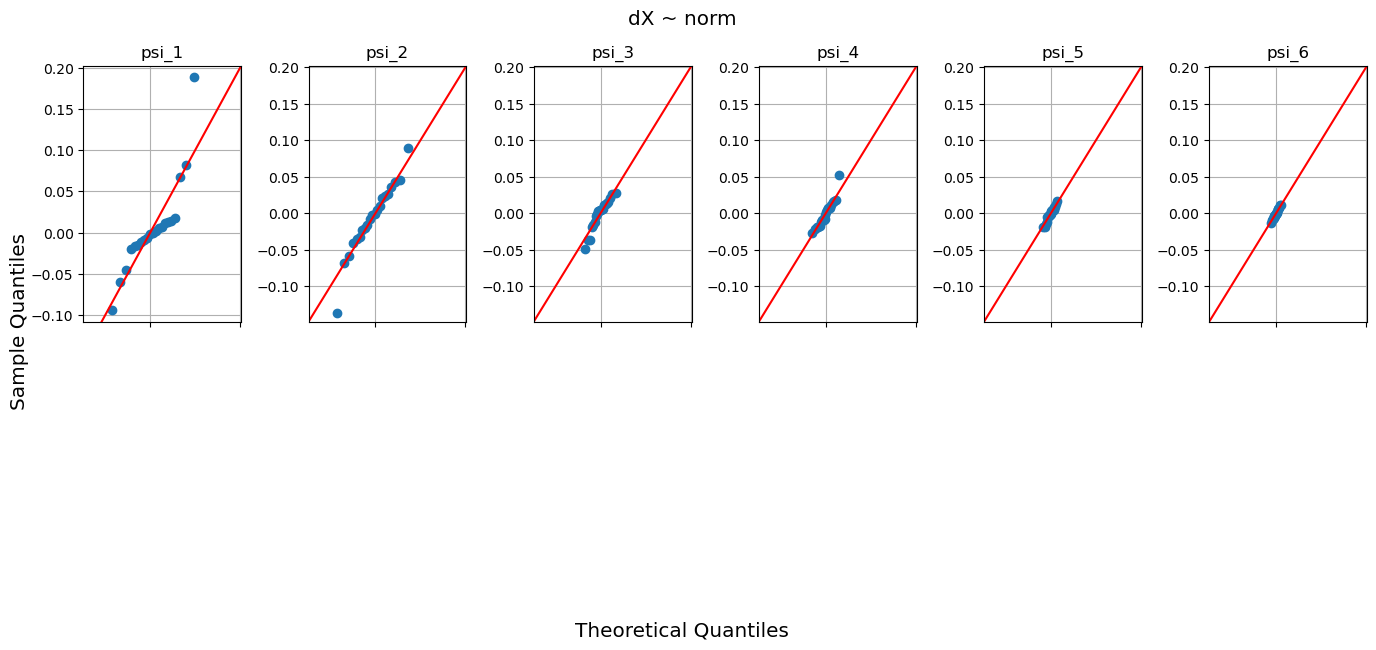

INFO:plots:2026-09-23 14:31:17.184978: psi_1: mean log-likelihood=1.7926, BIC=-66.1564
INFO:plots:2026-09-23 14:31:17.262453: psi_2: mean log-likelihood=1.6674, BIC=-60.8980
INFO:plots:2026-09-23 14:31:17.386435: psi_3: mean log-likelihood=2.4843, BIC=-95.2069
INFO:plots:2026-09-23 14:31:17.476391: psi_4: mean log-likelihood=2.6533, BIC=-102.3043
INFO:plots:2026-09-23 14:31:17.599557: psi_5: mean log-likelihood=3.2600, BIC=-127.7874
INFO:plots:2026-09-23 14:31:17.718469: psi_6: mean log-likelihood=3.6158, BIC=-142.7302


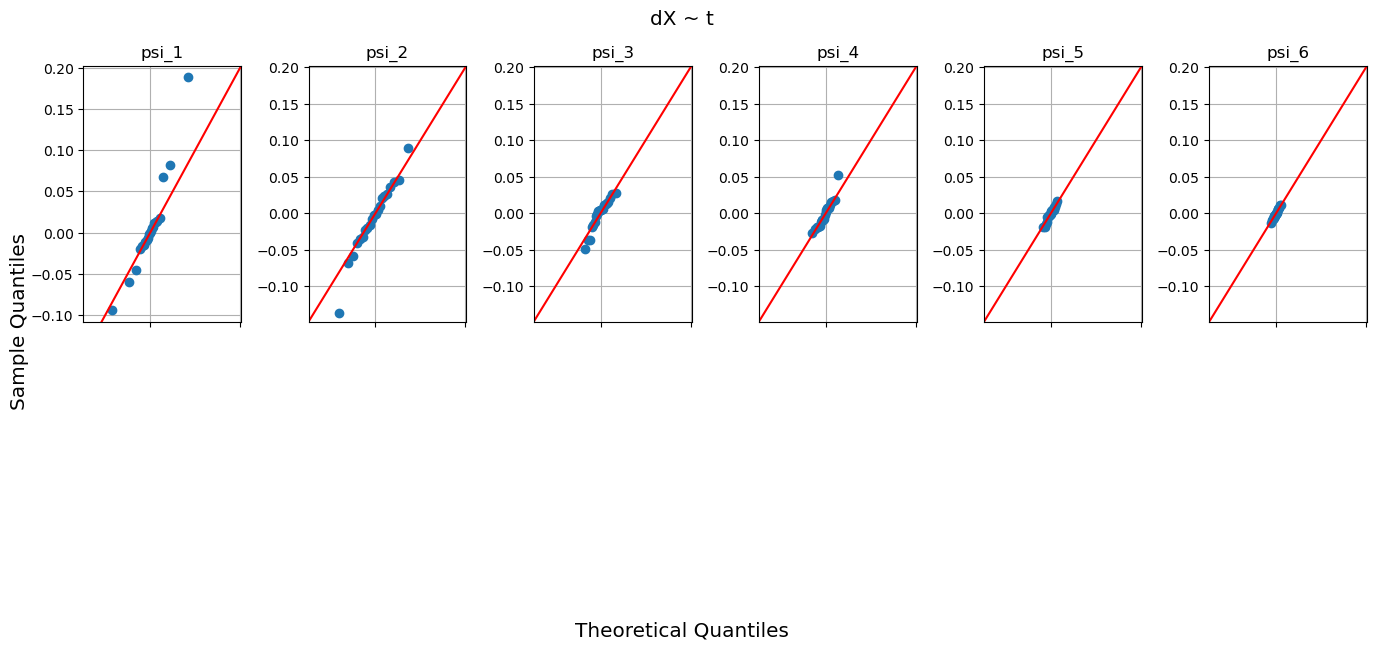

INFO:plots:2026-09-23 14:31:18.697214: psi_1: mean log-likelihood=1.8154, BIC=-64.0687
INFO:plots:2026-09-23 14:31:18.734000: psi_2: mean log-likelihood=1.6788, BIC=-58.3294
INFO:plots:2026-09-23 14:31:18.808352: psi_3: mean log-likelihood=2.5879, BIC=-96.5130
INFO:plots:2026-09-23 14:31:18.885342: psi_4: mean log-likelihood=2.7177, BIC=-101.9661
INFO:plots:2026-09-23 14:31:18.990956: psi_5: mean log-likelihood=3.2659, BIC=-124.9885
INFO:plots:2026-09-23 14:31:19.085945: psi_6: mean log-likelihood=3.6198, BIC=-139.8533
INFO:plots:Runtime error with psi_5: failed to compute the ppf of norminvgauss.


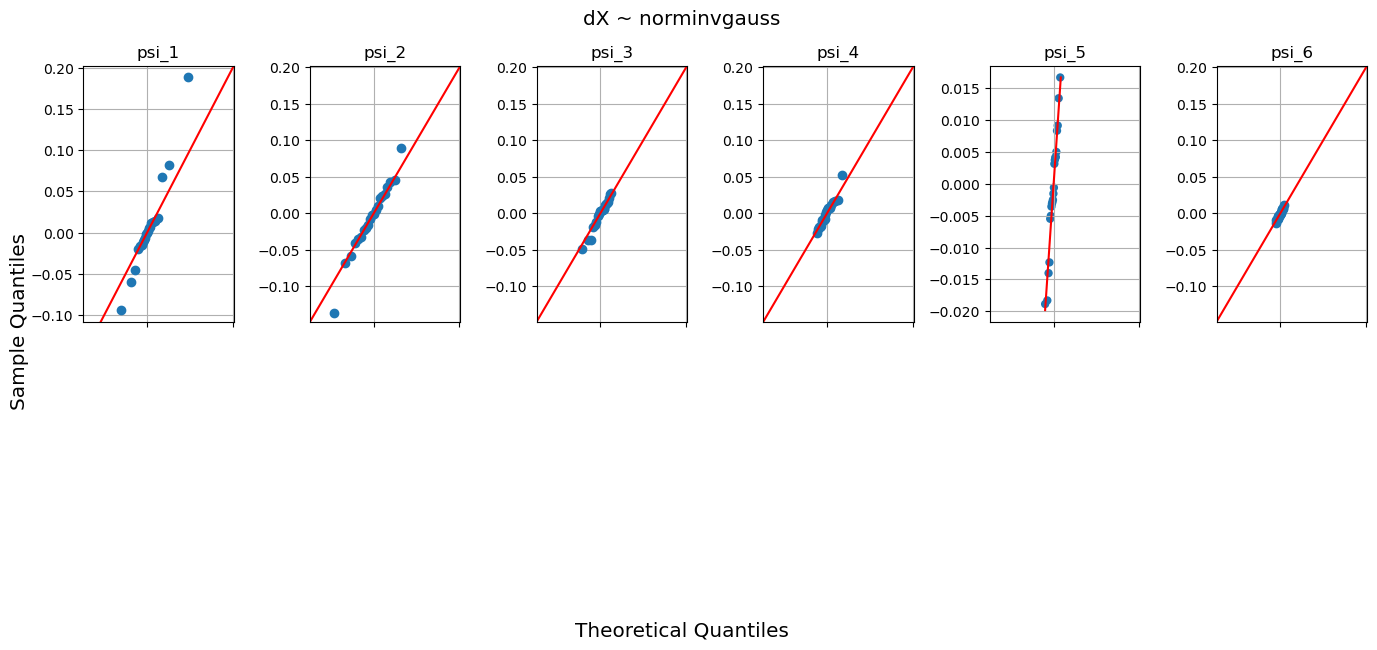

In [50]:
for dist in [norm, t, norminvgauss]:
    distribution_diagnostics(neural_pe, dist, qq=True)
    plt.show()

#### GPD Fits

In [36]:
def fit_gpd_ci(
        data: np.ndarray,
        ptile: float,
        n_boot: int=500,
        tail: Literal["left", "right"]="right"
    ) -> pd.DataFrame:
    u = np.percentile(data, ptile)

    if tail=="right":
        exceedences =  (data[data >  u] - u)
    else:
        exceedences = -(data[data < -u] + u)

    xi, loc, scale = genpareto.fit(data=exceedences, floc=0)  # already doing -u

    # bootstrap CIs
    boot = genpareto.rvs(xi, 0, scale, size=(n_boot, len(exceedences)))
    ests = np.asarray([genpareto.fit(sample, floc=0) for sample in boot])
    ci = np.percentile(ests, [2.5, 97.5], axis=0)
    se = ests.std(axis=0, ddof=1)

    ret = pd.DataFrame(
        index = [    "ci_lower", "value", "ci_upper",  "se", "tail",     "col"],
        data  = {
            "xi"   : [ci[0, 0] , xi     , ci[1, 0]  , se[0], tail  , data.name],
            "scale": [ci[0, 2] , scale  , ci[1, 2]  , se[2], tail  , data.name],
        }
    )

    return ret.T

In [37]:
def fit_exceedences(df: pd.DataFrame, percentiles: np.ndarray|None=None):
    if percentiles is None:
        percentiles = np.arange(90, 100, 0.5)

    gpd_results = {}

    for col in df.columns:
        data = df[col].diff().dropna()
        U = np.percentile(data, percentiles)
        param = {}

        for p, u in zip(percentiles, U):
            exceedences = data[data>u] -u
            logger.info(
                f"{datetime.now()}: {col}, {p:.2f}: {len(exceedences)} "
                " samples"
            )
            xi, loc, scale = genpareto.fit(exceedences, floc=0.0)
            param[p] = xi

        gpd_results[col] = param

    return pd.DataFrame(gpd_results)

In [38]:
def plot_param_stability(gpd_results: pd.DataFrame) -> Figure:
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharex=True)
    axes = np.ravel(axes)

    for col in gpd_results.columns:
        axes[0].plot(gpd_results[col], label=col, alpha=0.8)
        axes[0].set_ylabel(r"$\xi$")
        axes[0].set_title(
            r"Parameter stability plot: percentiles vs. GPD $\xi$"
        )
        axes[0].minorticks_on()
        axes[0].grid(which="major", linestyle='-', visible=True)
        axes[0].grid(which="minor", linestyle="--", alpha=0.8, visible=True)
        axes[0].legend()

        axes[1].plot(gpd_results[col].diff(), label=col, alpha=0.8)
        axes[1].set_ylabel(r"$\Delta\xi$")
        axes[1].set_title(
            r"Parameter stability plot: percentiles vs. $\Delta\xi$"
        )
        axes[1].minorticks_on()
        axes[1].grid(which="major", linestyle='-', visible=True)
        axes[1].grid(which="minor", linestyle="--", alpha=0.8, visible=True)
        axes[1].legend()

    fig.supxlabel("Percentile", fontsize="x-large")
    fig.tight_layout()
    return fig

In [39]:
def compute_gpd_cis(
        df: pd.DataFrame,
        ptile: float=97.5,
        n_boot: int=2_500,
        tail: Literal["left", "right"]="left"
    ) -> list:
    if not (0 < ptile < 100):
        raise ValueError(
            f"{datetime.now()}: percentile argument `ptile` must be between "
            f"[0, 100], received `{ptile}` instead."
        )

    if tail not in ["left", "right"]:
        raise ValueError(
            f"{datetime.now()}: `tail` must be either 'left' or 'right', "
            f"received `{tail}` instead."
        )

    out = Parallel(n_jobs=8)(
        delayed(fit_gpd_ci)(col, ptile=97.5, n_boot=n_boot, tail=tail)
        for _, col in df.diff().dropna().items()
    )

    return out

INFO:__main__:2026-10-01 05:10:01.719391: psi_1, 90.00: 2  samples
INFO:__main__:2026-10-01 05:10:01.795679: psi_1, 90.50: 2  samples
INFO:__main__:2026-10-01 05:10:01.883970: psi_1, 91.00: 2  samples
INFO:__main__:2026-10-01 05:10:01.958969: psi_1, 91.50: 2  samples
INFO:__main__:2026-10-01 05:10:02.030515: psi_1, 92.00: 2  samples
INFO:__main__:2026-10-01 05:10:02.121046: psi_1, 92.50: 2  samples
INFO:__main__:2026-10-01 05:10:02.216621: psi_1, 93.00: 2  samples
INFO:__main__:2026-10-01 05:10:02.288670: psi_1, 93.50: 2  samples
INFO:__main__:2026-10-01 05:10:02.374387: psi_1, 94.00: 2  samples
INFO:__main__:2026-10-01 05:10:02.463275: psi_1, 94.50: 2  samples
INFO:__main__:2026-10-01 05:10:02.538351: psi_1, 95.00: 1  samples
INFO:__main__:2026-10-01 05:10:02.609815: psi_1, 95.50: 1  samples
INFO:__main__:2026-10-01 05:10:02.682866: psi_1, 96.00: 1  samples
INFO:__main__:2026-10-01 05:10:02.745010: psi_1, 96.50: 1  samples
INFO:__main__:2026-10-01 05:10:02.813674: psi_1, 97.00: 1  sam

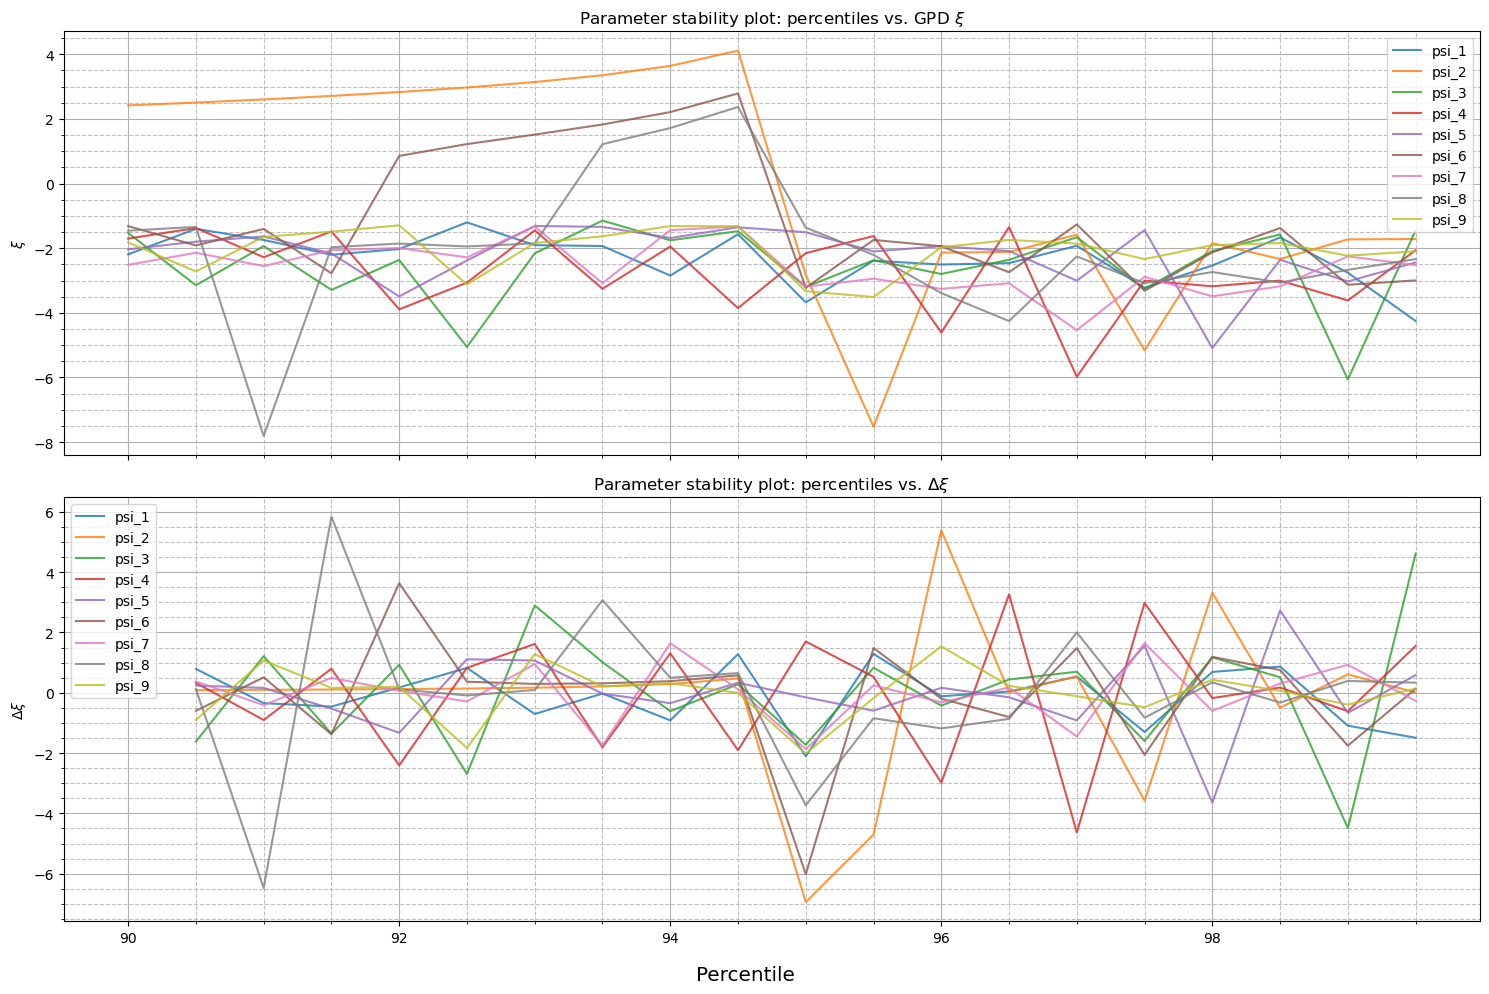

In [42]:
exceedences_ce = fit_exceedences(neural_ce)
plot_param_stability(exceedences_ce)
plt.show()

In [45]:
for tail in ["left", "right"]:
    _ = compute_gpd_cis(neural_ce, ptile=97.5, tail=tail)
    print(f"{tail}:")
    display(_)


KeyboardInterrupt



INFO:__main__:2026-10-01 05:10:47.041453: psi_1, 90.00: 2  samples
INFO:__main__:2026-10-01 05:10:47.121958: psi_1, 90.50: 2  samples
INFO:__main__:2026-10-01 05:10:47.194583: psi_1, 91.00: 2  samples
INFO:__main__:2026-10-01 05:10:47.275448: psi_1, 91.50: 2  samples
INFO:__main__:2026-10-01 05:10:47.369430: psi_1, 92.00: 2  samples
INFO:__main__:2026-10-01 05:10:47.453042: psi_1, 92.50: 2  samples
INFO:__main__:2026-10-01 05:10:47.559534: psi_1, 93.00: 2  samples
INFO:__main__:2026-10-01 05:10:47.648035: psi_1, 93.50: 2  samples
INFO:__main__:2026-10-01 05:10:47.735953: psi_1, 94.00: 2  samples
INFO:__main__:2026-10-01 05:10:47.761024: psi_1, 94.50: 2  samples
INFO:__main__:2026-10-01 05:10:47.788725: psi_1, 95.00: 1  samples
INFO:__main__:2026-10-01 05:10:47.856206: psi_1, 95.50: 1  samples
INFO:__main__:2026-10-01 05:10:47.913675: psi_1, 96.00: 1  samples
INFO:__main__:2026-10-01 05:10:47.989226: psi_1, 96.50: 1  samples
INFO:__main__:2026-10-01 05:10:48.071414: psi_1, 97.00: 1  sam

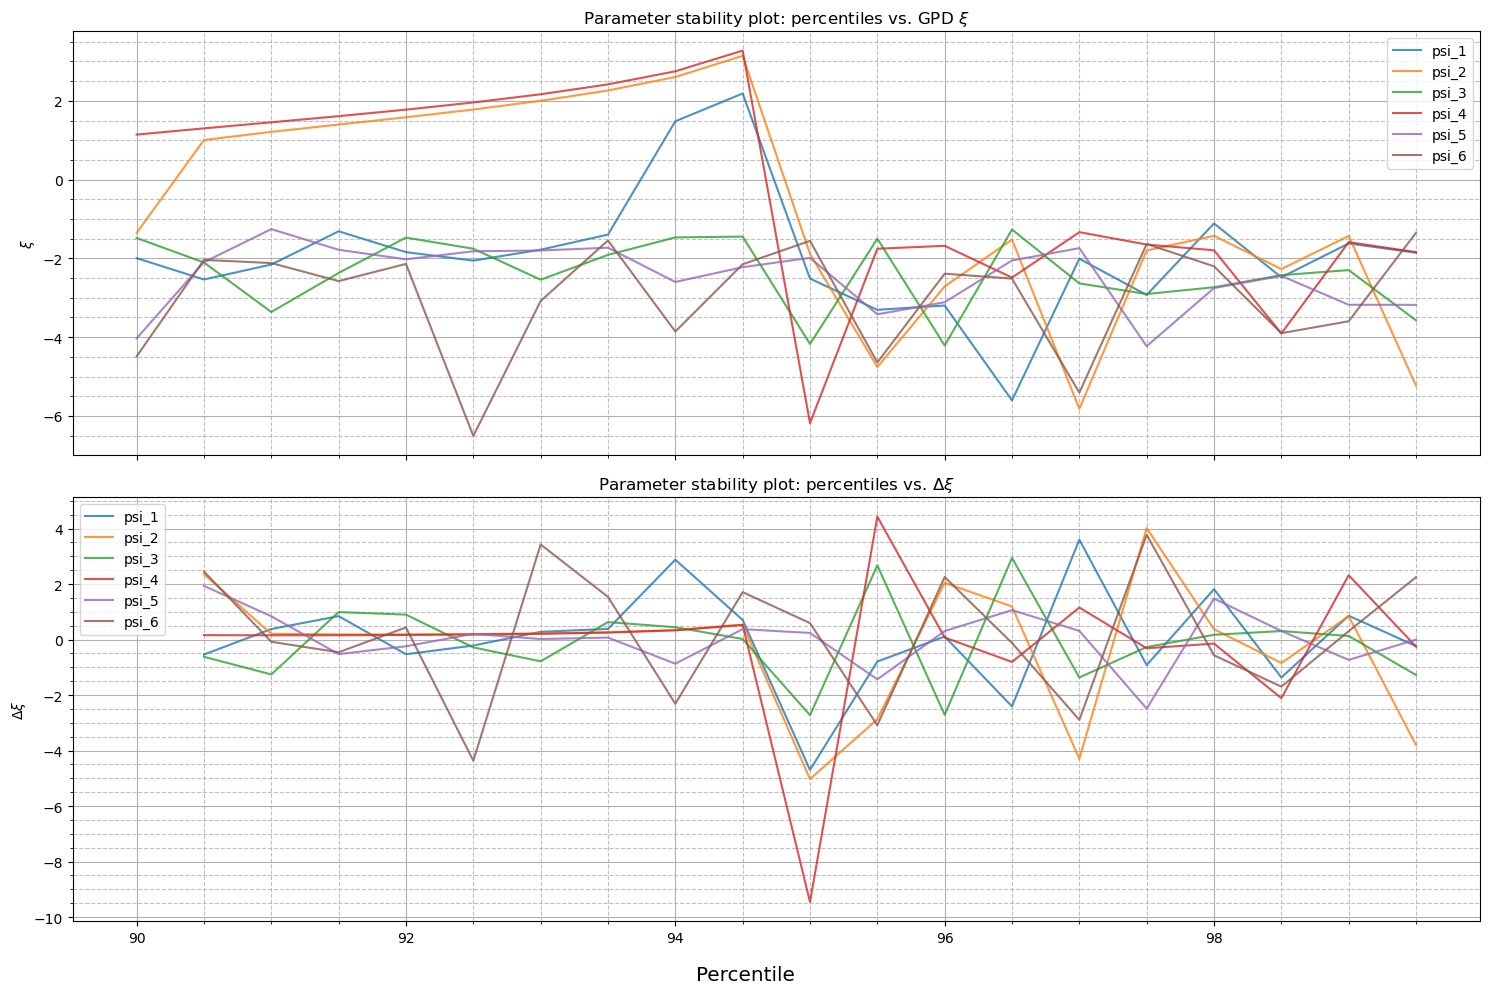

In [46]:
exceedences_pe = fit_exceedences(neural_pe)
plot_param_stability(exceedences_pe)
plt.show()

In [47]:
for tail in ["left", "right"]:
    _ = compute_gpd_cis(neural_pe, ptile=97.5, tail=tail)
    print(f"{tail}:")
    display(_)


KeyboardInterrupt



#### VIX rolling stable rank

In [48]:
def calculate_rolling_stable_rank(
        df: pd.DataFrame,
        window: int=30,
        step: int=1
    ) -> pd.Series:
    X = df.diff().dropna()
    ranks = []

    for start in range(0, len(X) - window + 1, step):
        win = X.iloc[start:start + window]
        Xc = win - win.mean(axis=0)
        fro_norm = np.linalg.norm(Xc, ord="fro")**2
        two_norm = np.linalg.norm(Xc, ord=2)**2
        stable_rank = fro_norm / two_norm
        ranks.append({str(win.index.max().date()): stable_rank})

    ranks_series = pd.Series({k: v for d in ranks for k, v in d.items()})
    ranks_series.index = pd.to_datetime(ranks_series.index)
    return ranks_series

In [49]:
vix_artefact = pd.read_csv(
    "./data/nifty-vix.csv",
    parse_dates = [0],
    index_col   = [0]
)

vix_artefact = (
    vix_artefact
    .loc[:, "close"]
    .rolling(30)
    .mean()
    .resample("15D")
    .mean()
)

TypeError: no numeric data to plot

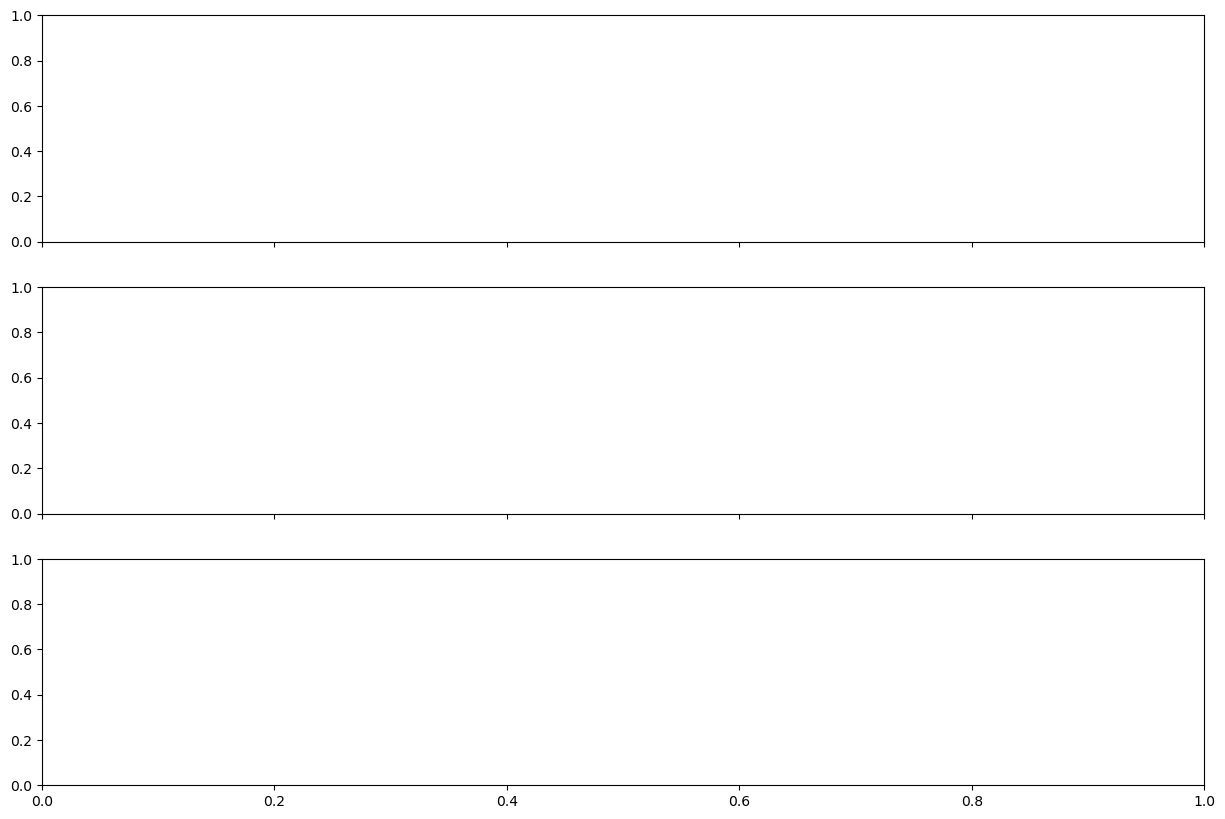

In [51]:
datasets = {
    "neural_ce": neural_ce,
    "neural_pe": neural_pe,
    "vix"      : vix_artefact,
}

panel_names = list(datasets.keys())
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 10), sharex=True)
for ax, name in zip(axes, panel_names):
    if name == "vix":
        datasets[name].plot(ax=ax, legend=False)
        ax.set_title(
            "15-day aggregated Nifty 50 VIX over [30::1] day rolling windows"
        )

        ax.set_ylabel("Level", fontsize="x-large")
        ax.yaxis.set_label_position("left")
    else:
        data_ranks = calculate_rolling_stable_rank(
            datasets[name],
            window = 30,
            step   = 1
        )
        (
            data_ranks
            .resample("15D")
            .agg("mean")
            .plot(ax=ax, legend=False)
        )
        _text = (
            "$\overline{{\operatorname{{sr}}}} "
            "(d\Xi^{{{name.split('_')[-1].upper()}}})$"
        )
        ax.set_title(rf"15-day {text} over [30::1] day rolling windows")
        ax.set_ylabel("") # Cleared for the custom shared label

    ax.set_xlabel("")
    ax.grid(True)
    ax.yaxis.tick_right()

fig.text(
    0.02, 0.67, "Stable Rank",
    va       = "center",
    ha       = "center",
    rotation = "vertical",
    fontsize = "x-large"
)
fig.supxlabel("Date", fontsize="x-large")
fig.tight_layout()
plt.show()